# Práctica B2-2: Motor de Stress Testing
## Escenarios de Estrés y Cambios de Régimen de Mercado
### Módulo de Gestión de Riesgos — MIAX

**Objetivo:** Construir un motor de *stress testing* capaz de capturar el riesgo de cola y los cambios de régimen, identificando cuándo el mercado entra en "crisis" y cuantificando el riesgo real cuando la diversificación desaparece.

**Tecnología permitida:** Hidden Markov Models, Cópulas, Simulación Monte Carlo.
**Tecnología prohibida:** Deep Learning y modelos opacos.

---

In [179]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from hmmlearn.hmm import GaussianHMM
from sklearn.preprocessing import StandardScaler
from matplotlib.patches import Patch
import warnings
from scipy.ndimage import median_filter
from copulae import GaussianCopula, StudentCopula
from scipy.stats import t
warnings.filterwarnings('ignore')

# Configuración de gráficos
plt.rcParams['figure.figsize'] = (16, 6)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')

# Semilla para reproducibilidad
SEED = 42
np.random.seed(SEED)

print("Librerías cargadas correctamente.")

Librerías cargadas correctamente.


---
## 1. Descarga de Datos

**Fuentes:**
- **yfinance:** Precios de los 18 activos de la cartera + S&P 500 + VIX + Rendimiento 10Y.
- **FRED (vía CSV directo):** Spread HY (BAMLH0A0HYM2) + Rendimiento 2Y (DGS2).

**Período:** 2006-01-01 hasta la fecha disponible (datos diarios).

In [2]:
# ═══════════════════════════════════════════════════
# Configuración de tickers y fechas
# ═══════════════════════════════════════════════════

START_DATE = '2006-01-01'
END_DATE   = '2026-02-07'

# Activos de la cartera (según enunciado)
# Usamos IEF y SHY como proxies de bonos 10Y y 2Y del gobierno americano
PORTFOLIO_TICKERS = [
    'AAPL', 'AMZN', 'BAC', 'BRK-B', 'CVX', 'ENPH', 'GLD', 'GME',
    'GOOGL', 'JNJ', 'JPM', 'MSFT', 'NVDA', 'PG', 'XOM',
    'IEF',   # iShares 7-10 Year Treasury Bond ETF (proxy bono 10Y)
    'SHY',   # iShares 1-3 Year Treasury Bond ETF (proxy bono 2Y)
    'HYG'    # iShares iBoxx High Yield Corporate Bond ETF
]

# Indicadores de mercado (para features del HMM)
MARKET_TICKERS = ['^GSPC', '^VIX', '^TNX']

print(f"Período: {START_DATE} → {END_DATE}")
print(f"Activos en cartera: {len(PORTFOLIO_TICKERS)}")
print(f"Tickers: {', '.join(PORTFOLIO_TICKERS)}")

Período: 2006-01-01 → 2026-02-07
Activos en cartera: 18
Tickers: AAPL, AMZN, BAC, BRK-B, CVX, ENPH, GLD, GME, GOOGL, JNJ, JPM, MSFT, NVDA, PG, XOM, IEF, SHY, HYG


In [3]:
# ═══════════════════════════════════════════════════
# Descarga de datos de la cartera desde yfinance
# ═══════════════════════════════════════════════════

print("Descargando precios de la cartera...")
portfolio_raw = yf.download(PORTFOLIO_TICKERS, start=START_DATE, end=END_DATE)['Close']

# Asegurar que las columnas están en el orden deseado
portfolio_raw = portfolio_raw[PORTFOLIO_TICKERS]

print(f"\nDimensiones: {portfolio_raw.shape[0]} días × {portfolio_raw.shape[1]} activos")
print(f"Rango: {portfolio_raw.index[0]} → {portfolio_raw.index[-1]}")
portfolio_raw.tail(3)

Descargando precios de la cartera...


[*********************100%***********************]  18 of 18 completed



Dimensiones: 5056 días × 18 activos
Rango: 2006-01-03 00:00:00 → 2026-02-06 00:00:00


Ticker,AAPL,AMZN,BAC,BRK-B,CVX,ENPH,GLD,GME,GOOGL,JNJ,JPM,MSFT,NVDA,PG,XOM,IEF,SHY,HYG
Date,,,,,,,,,,,,,,,,,,
2026-02-04,276.231506,232.990005,55.380001,503.829987,181.229996,51.669998,453.970001,24.980000,333.040009,234.470001,317.269989,414.190002,174.190002,156.869995,147.589996,95.510002,82.730003,80.620003
2026-02-05,275.652069,222.690002,54.939999,503.890015,179.229996,47.270000,441.880005,24.690001,331.250000,237.789993,310.160004,393.670013,171.880005,158.610001,146.080002,96.070000,82.860001,80.529999
2026-02-06,277.859985,210.320007,56.529999,508.089996,180.860001,49.799999,455.459991,24.980000,322.859985,239.990005,322.399994,401.140015,185.410004,159.169998,149.050003,96.070000,82.860001,80.809998


In [4]:
# ═══════════════════════════════════════════════════
# Descarga de indicadores de mercado desde yfinance
# S&P 500, VIX, Rendimiento del Tesoro 10Y
# ═══════════════════════════════════════════════════

print("Descargando indicadores de mercado...")
market_raw = yf.download(MARKET_TICKERS, start=START_DATE, end=END_DATE)['Close']

# Renombrar columnas para claridad
market_raw = market_raw.rename(columns={
    '^GSPC': 'SP500',
    '^VIX':  'VIX',
    '^TNX':  'TNX_10Y'
})

print(f"\nDimensiones: {market_raw.shape}")
market_raw.tail(3)

Descargando indicadores de mercado...


[*********************100%***********************]  3 of 3 completed


Dimensiones: (5056, 3)


Ticker,SP500,TNX_10Y,VIX
Date,,,
2026-02-04,6882.720215,4.275,18.639999
2026-02-05,6798.399902,4.210,21.770000
2026-02-06,6932.299805,4.206,20.370001


In [5]:
# ═══════════════════════════════════════════════════
# Descarga de datos de FRED (spread HY + yield 2Y)
# Usamos descarga directa vía CSV (evita problemas
# de compatibilidad de pandas-datareader con pandas 3.0)
# ═══════════════════════════════════════════════════

def download_fred_series(series_id, start, end):
    """Descarga una serie temporal de FRED directamente vía CSV."""
    url = (f'https://fred.stlouisfed.org/graph/fredgraph.csv'
           f'?id={series_id}&cosd={start}&coed={end}')
    df = pd.read_csv(url, index_col='observation_date', parse_dates=True)
    df.index.name = 'Date'
    # FRED usa '.' para valores no disponibles
    df[series_id] = pd.to_numeric(df[series_id], errors='coerce')
    return df

print("Descargando datos de FRED...")
print("  → BAMLH0A0HYM2 (ICE BofA US High Yield Spread)...")
hy_spread_fred = download_fred_series('BAMLH0A0HYM2', START_DATE, END_DATE)

print("  → DGS2 (Rendimiento del Tesoro 2Y)...")
ust_2y_fred = download_fred_series('DGS2', START_DATE, END_DATE)

# Combinar en un solo DataFrame
fred_data = pd.concat([hy_spread_fred, ust_2y_fred], axis=1)
fred_data.columns = ['HY_Spread', 'UST_2Y']

print(f"\nDimensiones FRED: {fred_data.shape}")
fred_data.tail(3)

Descargando datos de FRED...
  → BAMLH0A0HYM2 (ICE BofA US High Yield Spread)...
  → DGS2 (Rendimiento del Tesoro 2Y)...

Dimensiones FRED: (5312, 2)


,HY_Spread,UST_2Y
Date,,
2026-02-04,2.86,3.57
2026-02-05,2.97,3.47
2026-02-06,2.87,3.50


In [6]:
# ═══════════════════════════════════════════════════
# Resumen de disponibilidad de datos por activo
# ═══════════════════════════════════════════════════

print("=" * 65)
print("DISPONIBILIDAD DE DATOS POR ACTIVO")
print("=" * 65)

print("\n--- Cartera ---")
for col in portfolio_raw.columns:
    valid = portfolio_raw[col].dropna()
    if len(valid) > 0:
        print(f"  {col:8s}: {valid.index[0].strftime('%Y-%m-%d')} → "
              f"{valid.index[-1].strftime('%Y-%m-%d')}  ({len(valid):>5,} obs)")
    else:
        print(f"  {col:8s}: SIN DATOS")

print("\n--- Indicadores de mercado ---")
for col in market_raw.columns:
    valid = market_raw[col].dropna()
    print(f"  {col:8s}: {valid.index[0].strftime('%Y-%m-%d')} → "
          f"{valid.index[-1].strftime('%Y-%m-%d')}  ({len(valid):>5,} obs)")

print("\n--- FRED ---")
for col in fred_data.columns:
    valid = fred_data[col].dropna()
    print(f"  {col:12s}: {valid.index[0].strftime('%Y-%m-%d')} → "
          f"{valid.index[-1].strftime('%Y-%m-%d')}  ({len(valid):>5,} obs)")

DISPONIBILIDAD DE DATOS POR ACTIVO

--- Cartera ---
  AAPL    : 2006-01-03 → 2026-02-06  (5,056 obs)
  AMZN    : 2006-01-03 → 2026-02-06  (5,056 obs)
  BAC     : 2006-01-03 → 2026-02-06  (5,056 obs)
  BRK-B   : 2006-01-03 → 2026-02-06  (5,056 obs)
  CVX     : 2006-01-03 → 2026-02-06  (5,056 obs)
  ENPH    : 2012-03-30 → 2026-02-06  (3,484 obs)
  GLD     : 2006-01-03 → 2026-02-06  (5,056 obs)
  GME     : 2006-01-03 → 2026-02-06  (5,056 obs)
  GOOGL   : 2006-01-03 → 2026-02-06  (5,056 obs)
  JNJ     : 2006-01-03 → 2026-02-06  (5,056 obs)
  JPM     : 2006-01-03 → 2026-02-06  (5,056 obs)
  MSFT    : 2006-01-03 → 2026-02-06  (5,056 obs)
  NVDA    : 2006-01-03 → 2026-02-06  (5,056 obs)
  PG      : 2006-01-03 → 2026-02-06  (5,056 obs)
  XOM     : 2006-01-03 → 2026-02-06  (5,056 obs)
  IEF     : 2006-01-03 → 2026-02-06  (5,056 obs)
  SHY     : 2006-01-03 → 2026-02-06  (5,056 obs)
  HYG     : 2007-04-11 → 2026-02-06  (4,738 obs)

--- Indicadores de mercado ---
  SP500   : 2006-01-03 → 2026-02-0

---
## 2. Limpieza y Preparación de Datos

- Eliminamos timezone info de yfinance para alinear con FRED.
- Forward-fill de hasta 5 días para cubrir festivos.
- Reindexamos FRED al calendario de mercado (días bursátiles).

In [7]:
# ═══════════════════════════════════════════════════
# Limpieza y alineación de datos
# ═══════════════════════════════════════════════════

# 1. Eliminar timezone info de yfinance (FRED no la tiene)
for df in [portfolio_raw, market_raw]:
    if df.index.tz is not None:
        df.index = df.index.tz_localize(None)

# 2. Forward-fill para cubrir días festivos (máximo 5 días)
portfolio = portfolio_raw.ffill(limit=5)
market    = market_raw.ffill(limit=5)

# 3. Reindexar FRED al mismo calendario que mercado
fred = fred_data.reindex(market.index).ffill(limit=5)

# 4. Log-retornos diarios de la cartera (se usarán en fases posteriores)
portfolio_returns = np.log(portfolio / portfolio.shift(1))

# 5. Resumen de NaN restantes
print("NaN restantes tras limpieza:")
print(f"  Cartera: {portfolio.isna().sum().sum()} "
      f"(de {portfolio.shape[0] * portfolio.shape[1]} celdas)")
print(f"  Market:  {market.isna().sum().sum()}")
print(f"  FRED:    {fred.isna().sum().sum()}")

# Mostrar activos con NaN significativos
nan_by_asset = portfolio.isna().sum()
problematic = nan_by_asset[nan_by_asset > 0]
if len(problematic) > 0:
    print("\nActivos con NaN (datos no disponibles al inicio):")
    for asset, n in problematic.items():
        first_valid = portfolio[asset].first_valid_index()
        print(f"  {asset}: {n} NaN → datos disponibles desde {first_valid.strftime('%Y-%m-%d')}")

NaN restantes tras limpieza:
  Cartera: 1890 (de 91008 celdas)
  Market:  0
  FRED:    0

Activos con NaN (datos no disponibles al inicio):
  ENPH: 1572 NaN → datos disponibles desde 2012-03-30
  HYG: 318 NaN → datos disponibles desde 2007-04-11


---
## 3. Fase 1 — Detección del "Pulso" del Mercado (Hidden Markov Model)

**Objetivo:** Identificar, para cada día, si el mercado se encuentra en un estado de **calma** o de **crisis**, utilizando un Gaussian HMM de 2 estados.

### Justificación de las variables elegidas para el HMM

Utilizamos **4 factores** que capturan distintas dimensiones del riesgo sistémico:

| Factor | Variable | Justificación económica |
|--------|----------|------------------------|
| **Equity** | Retorno rolling 5d del S&P 500 | Captura el momentum/dirección del mercado de renta variable |
| **Volatilidad** | VIX (nivel) | Mide el miedo del mercado (volatilidad implícita de opciones del S&P 500) |
| **Crédito** | Spread HY (BAMLH0A0HYM2) | Indica estrés en el mercado de crédito y aversión al riesgo |
| **Tipos de interés** | Pendiente curva 10Y-2Y | Señala expectativas macro: inversión → recesión esperada |

Usamos **rolling 5 días** para el retorno del S&P 500 para reducir el ruido diario y capturar tendencias de corto plazo más estables.

In [8]:
# ═══════════════════════════════════════════════════
# 3.1 Construcción de features para el HMM
# ═══════════════════════════════════════════════════

# Feature 1: Retorno logarítmico rolling 5 días del S&P 500
# Captura la dirección/momentum del mercado con menos ruido que retornos diarios
sp500_ret_5d = np.log(market['SP500'] / market['SP500'].shift(10))

# Feature 2: VIX (nivel)
# El "índice del miedo" — volatilidad implícita de opciones del S&P 500
vix = market['VIX']
#vix = np.log(market['VIX'] / market['VIX'].shift(10))

# Feature 3: Spread de crédito High Yield (FRED: BAMLH0A0HYM2)
# Diferencia entre rendimientos de bonos HY y Tesoro — indica estrés crediticio
hy_spread = fred['HY_Spread']
#hy_spread = np.log(fred['HY_Spread'] / fred['HY_Spread'].shift(10))

# Feature 4: Pendiente de la curva de tipos (10Y - 2Y)
# Positiva en expansión, se aplana/invierte antes de recesiones
yield_slope = market['TNX_10Y'] - fred['UST_2Y']
#yield_slope = np.log((market['TNX_10Y'] - fred['UST_2Y']) / (market['TNX_10Y'] - fred['UST_2Y']).shift(10))

# Combinar en DataFrame
hmm_features = pd.DataFrame({
    'SP500_Ret5d': sp500_ret_5d,
    'VIX': vix,
    'HY_Spread': hy_spread,
    'Yield_Slope': yield_slope
}, index=market.index)

# Eliminar filas con NaN (necesario para el HMM)
hmm_features = hmm_features.dropna()

print(f"Features para el HMM: {hmm_features.shape[0]} observaciones × {hmm_features.shape[1]} features")
print(f"Rango efectivo: {hmm_features.index[0].strftime('%Y-%m-%d')} → "
      f"{hmm_features.index[-1].strftime('%Y-%m-%d')}")
print(f"\nEstadísticas descriptivas:")
hmm_features.describe().round(4)

Features para el HMM: 5046 observaciones × 4 features
Rango efectivo: 2006-01-18 → 2026-02-06

Estadísticas descriptivas:


,SP500_Ret5d,VIX,HY_Spread,Yield_Slope
count,5046.0000,5046.0000,5046.0000,5046.0000
mean,0.0033,19.4644,5.1053,0.9936
std,0.0335,8.7193,2.6677,0.9550
min,-0.2995,9.1400,2.4100,-1.0820
25%,-0.0099,13.7400,3.5000,0.2050
50%,0.0072,17.0800,4.3800,0.9370
75%,0.0212,22.4700,5.8475,1.7130
max,0.1959,82.6900,21.8200,2.9030



Primeras 10 observaciones:
            SP500_Ret5d     VIX  HY_Spread  Yield_Slope
Date                                                   
2006-01-18       0.1142 -0.8275    -0.5493      -1.0300
2006-01-19       0.1703 -0.8584    -0.5718      -1.0311
2006-01-20      -0.3819 -0.5625    -0.5643      -1.0499
2006-01-23      -0.6060 -0.6348    -0.5681      -1.0332
2006-01-24      -0.6432 -0.7059    -0.5868      -1.0196
2006-01-25      -0.6839 -0.7564    -0.6243      -1.0206
2006-01-26      -0.5726 -0.8080    -0.6318      -1.0059
2006-01-27      -0.1541 -0.8596    -0.6393      -1.0478
2006-01-30      -0.1559 -0.8114    -0.6618      -1.0248
2006-01-31      -0.1661 -0.7472    -0.6318      -1.0541


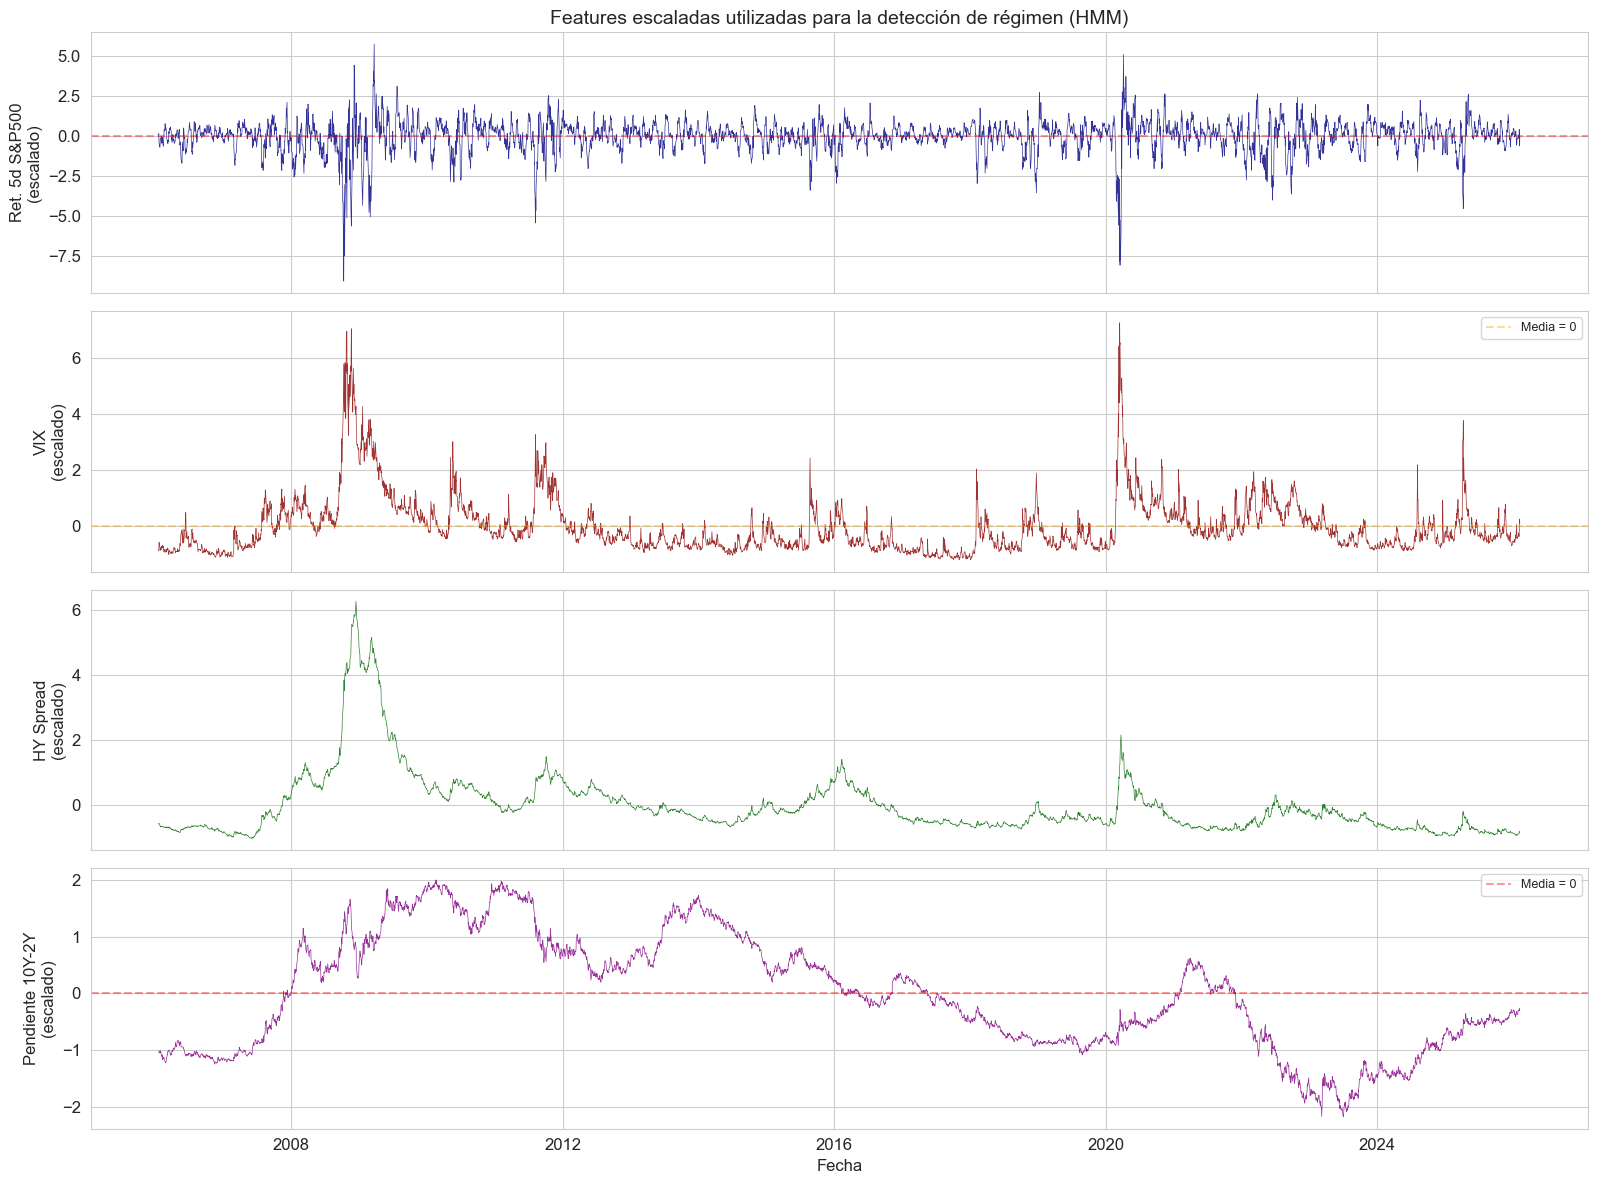

In [9]:
# ═══════════════════════════════════════════════════
# Visualización de las features del HMM
# ═══════════════════════════════════════════════════
scaler = StandardScaler()
X_scaled = scaler.fit_transform(hmm_features.values)

print(f"\nPrimeras 10 observaciones:")
scaled_df = pd.DataFrame(X_scaled, 
                        columns=hmm_features.columns, 
                        index=hmm_features.index)
print(scaled_df.head(10).round(4))

fig, axes = plt.subplots(4, 1, figsize=(16, 12), sharex=True)

# S&P 500 retorno rolling 5d (escalado)
axes[0].plot(hmm_features.index, X_scaled[:, 0],
             color='navy', linewidth=0.5, alpha=0.8)
axes[0].axhline(0, color='red', linestyle='--', alpha=0.4)
axes[0].set_ylabel('Ret. 5d S&P500\n(escalado)')
axes[0].set_title('Features escaladas utilizadas para la detección de régimen (HMM)', fontsize=14)

# VIX (escalado)
axes[1].plot(hmm_features.index, X_scaled[:, 1],
             color='darkred', linewidth=0.5, alpha=0.8)
axes[1].axhline(0, color='orange', linestyle='--', alpha=0.4, label='Media = 0')
axes[1].set_ylabel('VIX\n(escalado)')
axes[1].legend(fontsize=9)

# HY Spread (escalado)
axes[2].plot(hmm_features.index, X_scaled[:, 2],
             color='darkgreen', linewidth=0.5, alpha=0.8)
axes[2].set_ylabel('HY Spread\n(escalado)')

# Pendiente curva de tipos (escalado)
axes[3].plot(hmm_features.index, X_scaled[:, 3],
             color='purple', linewidth=0.5, alpha=0.8)
axes[3].axhline(0, color='red', linestyle='--', alpha=0.4, label='Media = 0')
axes[3].set_ylabel('Pendiente 10Y-2Y\n(escalado)')
axes[3].set_xlabel('Fecha')
axes[3].legend(fontsize=9)

plt.tight_layout()
plt.show()

### 3.2 Ajuste del Gaussian HMM (2 estados)

Ajustamos un **Gaussian HMM con 2 componentes** (calma y crisis) sobre las 4 features estandarizadas.

- **Tipo de covarianza:** `full` — permite capturar correlaciones entre features dentro de cada estado.
- **Múltiples inicializaciones:** Probamos 10 semillas distintas y nos quedamos con el modelo con mejor log-likelihood, para evitar óptimos locales.
- **Estandarización:** Normalizamos las features a media 0 y desviación 1 para que el HMM no esté dominado por la escala del VIX o del spread.

In [10]:
# ═══════════════════════════════════════════════════
# 3.2 Ajuste del Gaussian HMM
# ═══════════════════════════════════════════════════

# Estandarizar features (media=0, std=1)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(hmm_features.values)

#X_scaled = X_scaled['Yield_Slope']

# Ajustar HMM con múltiples inicializaciones para evitar óptimos locales
best_model = None
best_score = -np.inf

print("Ajustando HMM con 10 inicializaciones distintas...")
for attempt in range(10):
    model = GaussianHMM(
        n_components=2,
        covariance_type='full',  # Covarianza completa: captura correlaciones entre features
        n_iter=1000,
        random_state=SEED + attempt,
        tol=1e-4
    )
    model.fit(X_scaled)
    score = model.score(X_scaled)
    if score > best_score:
        best_score = score
        best_model = model
        best_attempt = attempt
    print(f"  Intento {attempt}: log-likelihood = {score:,.2f}"
          f"{' ← mejor' if score == best_score else ''}")

print(f"\nMejor modelo: intento {best_attempt}, log-likelihood = {best_score:,.2f}")
print(f"Convergencia: {best_model.monitor_.converged}")

Ajustando HMM con 10 inicializaciones distintas...
  Intento 0: log-likelihood = -19,325.04 ← mejor
  Intento 1: log-likelihood = -19,325.04
  Intento 2: log-likelihood = -19,325.04
  Intento 3: log-likelihood = -19,325.04
  Intento 4: log-likelihood = -19,325.04
  Intento 5: log-likelihood = -19,325.04
  Intento 6: log-likelihood = -19,325.04
  Intento 7: log-likelihood = -19,325.04
  Intento 8: log-likelihood = -19,325.04
  Intento 9: log-likelihood = -19,325.04

Mejor modelo: intento 0, log-likelihood = -19,325.04
Convergencia: True


In [11]:
# ═══════════════════════════════════════════════════
# Identificación y etiquetado de estados
# ═══════════════════════════════════════════════════

# Predecir estados y probabilidades
hidden_states = best_model.predict(X_scaled)
state_probs   = best_model.predict_proba(X_scaled)

# Medias de cada feature en cada estado (escala original)
state_means_original = scaler.inverse_transform(best_model.means_)
state_means_df = pd.DataFrame(
    state_means_original,
    columns=hmm_features.columns,
    index=['Estado 0', 'Estado 1']
)

print("Medias de cada feature por estado (escala original):")
print(state_means_df.round(4).to_string())

# ─── Criterio de asignación ───
# El estado con VIX medio más alto = Crisis
# (en crisis, la volatilidad implícita sube significativamente)
crisis_state_id = int(state_means_df['VIX'].values.argmax())
calm_state_id   = 1 - crisis_state_id

print(f"\n→ Estado {calm_state_id} = CALMA  (VIX medio: {state_means_df.iloc[calm_state_id]['VIX']:.4f})")
print(f"→ Estado {crisis_state_id} = CRISIS (VIX medio: {state_means_df.iloc[crisis_state_id]['VIX']:.4f})")

# Reasignar etiquetas para que 0 = Calma, 1 = Crisis
if crisis_state_id == 0:
    hidden_states = 1 - hidden_states
    state_probs = state_probs[:, ::-1]
    # Reordenar la tabla de medias
    state_means_df = state_means_df.iloc[::-1].reset_index(drop=True)
    state_means_df.index = ['Calma', 'Crisis']
else:
    state_means_df.index = ['Calma', 'Crisis']

# Serie temporal de regímenes
regimes = pd.Series(hidden_states, index=hmm_features.index, name='regime')
filtered_values = median_filter(regimes, size=100)
regimes = pd.Series(filtered_values, index=hmm_features.index, name='regime')

print(f"\nEstados reasignados: 0 = Calma, 1 = Crisis")

Medias de cada feature por estado (escala original):
          SP500_Ret5d      VIX  HY_Spread  Yield_Slope
Estado 0      -0.0056  28.2890     7.1944       1.2330
Estado 1       0.0076  15.2249     4.1017       0.8786

→ Estado 1 = CALMA  (VIX medio: 15.2249)
→ Estado 0 = CRISIS (VIX medio: 28.2890)

Estados reasignados: 0 = Calma, 1 = Crisis


In [12]:
# ═══════════════════════════════════════════════════
# Análisis detallado de los estados del HMM
# ═══════════════════════════════════════════════════

# --- Matriz de transición ---
transmat = best_model.transmat_.copy()
if crisis_state_id == 0:
    transmat = transmat[::-1, ::-1]

print("=" * 55)
print("MATRIZ DE TRANSICIÓN (probabilidades diarias)")
print("=" * 55)
print(f"{'':15s} {'→ Calma':>12s} {'→ Crisis':>12s}")
print(f"{'Calma →':15s} {transmat[0,0]:12.4f} {transmat[0,1]:12.4f}")
print(f"{'Crisis →':15s} {transmat[1,0]:12.4f} {transmat[1,1]:12.4f}")

# --- Duración media esperada de cada estado ---
calm_duration   = 1 / (1 - transmat[0, 0])
crisis_duration = 1 / (1 - transmat[1, 1])

print(f"\n{'=' * 55}")
print("DURACIÓN MEDIA ESPERADA DE CADA ESTADO")
print(f"{'=' * 55}")
print(f"  Calma:   {calm_duration:6.1f} días  ({calm_duration/21:.1f} meses, {calm_duration/252:.1f} años)")
print(f"  Crisis:  {crisis_duration:6.1f} días  ({crisis_duration/21:.1f} meses, {crisis_duration/252:.1f} años)")

# --- Porcentaje de tiempo en cada estado ---
n_calm   = (regimes == 0).sum()
n_crisis = (regimes == 1).sum()
n_total  = len(regimes)

print(f"\n{'=' * 55}")
print("DISTRIBUCIÓN TEMPORAL DE ESTADOS")
print(f"{'=' * 55}")
print(f"  Calma:   {n_calm:>5d} días ({n_calm/n_total*100:.1f}%)")
print(f"  Crisis:  {n_crisis:>5d} días ({n_crisis/n_total*100:.1f}%)")
print(f"  Total:   {n_total:>5d} días")

# --- Número de cambios de régimen ---
state_changes = (regimes.diff().abs() > 0).sum()
print(f"\n  Cambios de régimen: {state_changes}")

# --- Tabla resumen de features por estado ---
print(f"\n{'=' * 55}")
print("ESTADÍSTICAS DE FEATURES POR ESTADO")
print(f"{'=' * 55}")

summary_rows = []
for state, label in [(0, 'Calma'), (1, 'Crisis')]:
    mask = regimes == state
    subset = hmm_features[mask]
    for col in hmm_features.columns:
        summary_rows.append({
            'Estado': label,
            'Feature': col,
            'Media': subset[col].mean(),
            'Desv. Std': subset[col].std(),
            'Mín': subset[col].min(),
            'Máx': subset[col].max()
        })

summary_df = pd.DataFrame(summary_rows)
print(summary_df.pivot_table(
    index='Feature', columns='Estado',
    values=['Media', 'Desv. Std']
).round(4).to_string())

MATRIZ DE TRANSICIÓN (probabilidades diarias)
                     → Calma     → Crisis
Calma →               0.9921       0.0079
Crisis →              0.0165       0.9835

DURACIÓN MEDIA ESPERADA DE CADA ESTADO
  Calma:    126.0 días  (6.0 meses, 0.5 años)
  Crisis:    60.6 días  (2.9 meses, 0.2 años)

DISTRIBUCIÓN TEMPORAL DE ESTADOS
  Calma:    3589 días (71.1%)
  Crisis:   1457 días (28.9%)
  Total:    5046 días

  Cambios de régimen: 12

ESTADÍSTICAS DE FEATURES POR ESTADO
            Desv. Std             Media         
Estado          Calma   Crisis    Calma   Crisis
Feature                                         
HY_Spread      1.0114   3.7236   4.1208   7.5304
SP500_Ret5d    0.0229   0.0506   0.0055  -0.0019
VIX            4.0069  10.5996  15.8501  28.3672
Yield_Slope    0.9629   0.8606   0.8678   1.3034


### 3.3 Visualización: S&P 500 por Régimen Detectado

El gráfico principal muestra el S&P 500 con el fondo coloreado según el estado detectado por el HMM:
- **Fondo blanco** = Estado de **Calma**
- **Fondo azul** = Estado de **Crisis**

El panel inferior muestra la **probabilidad filtrada de estar en estado de crisis** en cada momento.

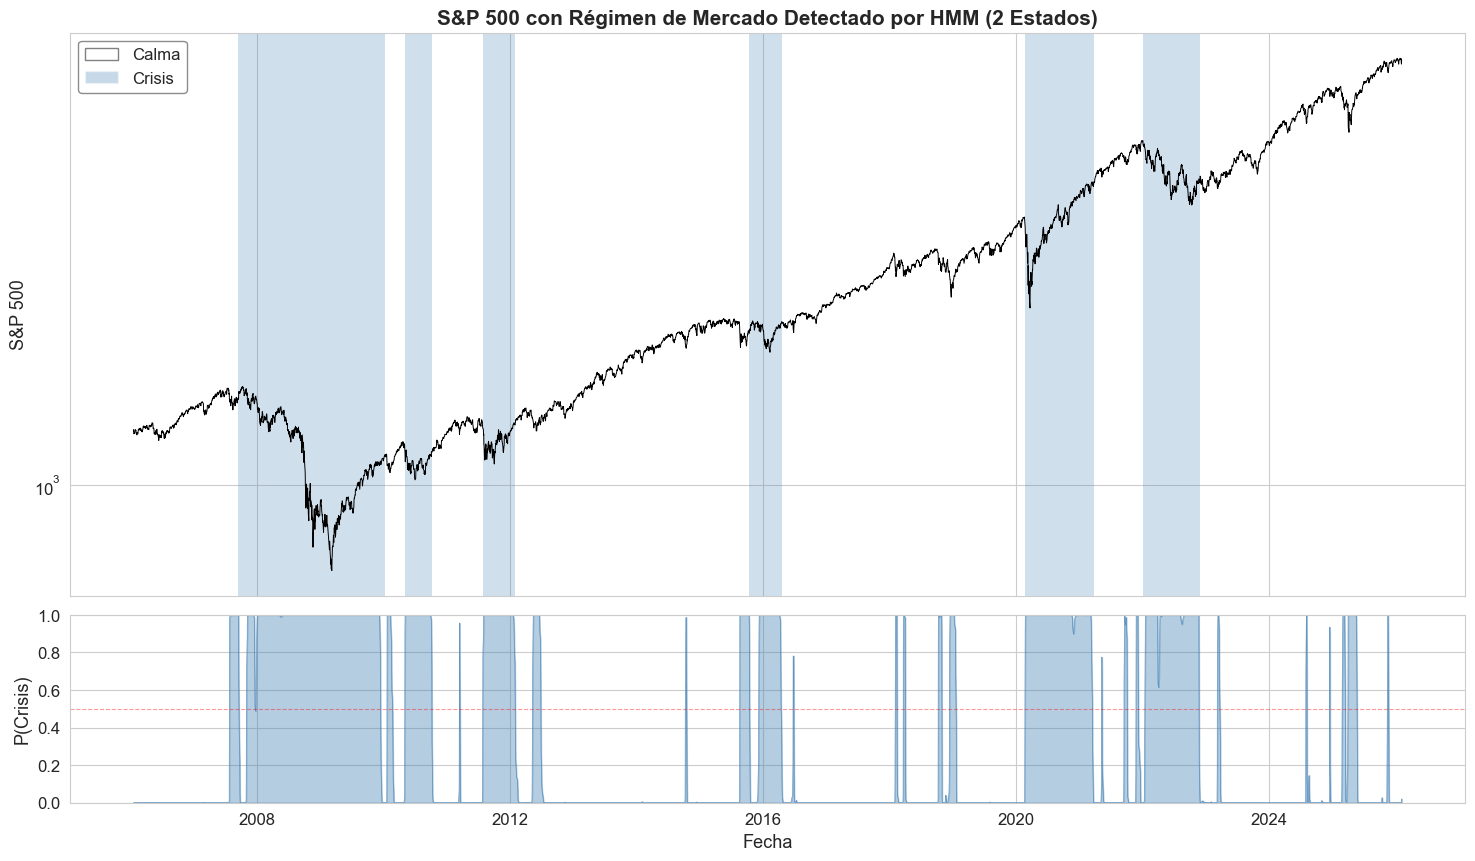

In [13]:
# ═══════════════════════════════════════════════════
# GRÁFICO PRINCIPAL: S&P 500 coloreado por régimen
# ═══════════════════════════════════════════════════

fig, axes = plt.subplots(2, 1, figsize=(18, 10),
                          height_ratios=[3, 1],
                          gridspec_kw={'hspace': 0.05})

# ─── Panel superior: S&P 500 con régimen ───
ax1 = axes[0]
sp500 = market['SP500'].loc[hmm_features.index]

# Colorear períodos de crisis con fondo azul
crisis_mask = regimes == 1
i = 0
while i < len(regimes):
    if crisis_mask.iloc[i]:
        # Encontrar el final del bloque de crisis
        j = i
        while j < len(regimes) and crisis_mask.iloc[j]:
            j += 1
        ax1.axvspan(regimes.index[i], regimes.index[min(j, len(regimes)-1)],
                    alpha=0.25, color='steelblue', linewidth=0)
        i = j
    else:
        i += 1

ax1.plot(sp500.index, sp500.values, color='black', linewidth=0.7)
ax1.set_ylabel('S&P 500', fontsize=13)
ax1.set_title('S&P 500 con Régimen de Mercado Detectado por HMM (2 Estados)',
              fontsize=15, fontweight='bold')
ax1.set_yscale('log')

# Leyenda
legend_elements = [
    Patch(facecolor='white', edgecolor='gray', label='Calma'),
    Patch(facecolor='steelblue', alpha=0.3, label='Crisis')
]
ax1.legend(handles=legend_elements, loc='upper left', fontsize=12,
           framealpha=0.9, edgecolor='gray')
ax1.tick_params(labelbottom=False)

# ─── Panel inferior: Probabilidad de crisis ───
ax2 = axes[1]
crisis_prob = pd.Series(state_probs[:, 1], index=hmm_features.index)

ax2.fill_between(crisis_prob.index, 0, crisis_prob.values,
                 color='steelblue', alpha=0.4)
ax2.plot(crisis_prob.index, crisis_prob.values,
         color='steelblue', linewidth=0.5, alpha=0.7)
ax2.set_ylabel('P(Crisis)', fontsize=13)
ax2.set_xlabel('Fecha', fontsize=13)
ax2.set_ylim(0, 1)
ax2.axhline(0.5, color='red', linestyle='--', alpha=0.4, linewidth=0.8)

plt.tight_layout()
plt.show()

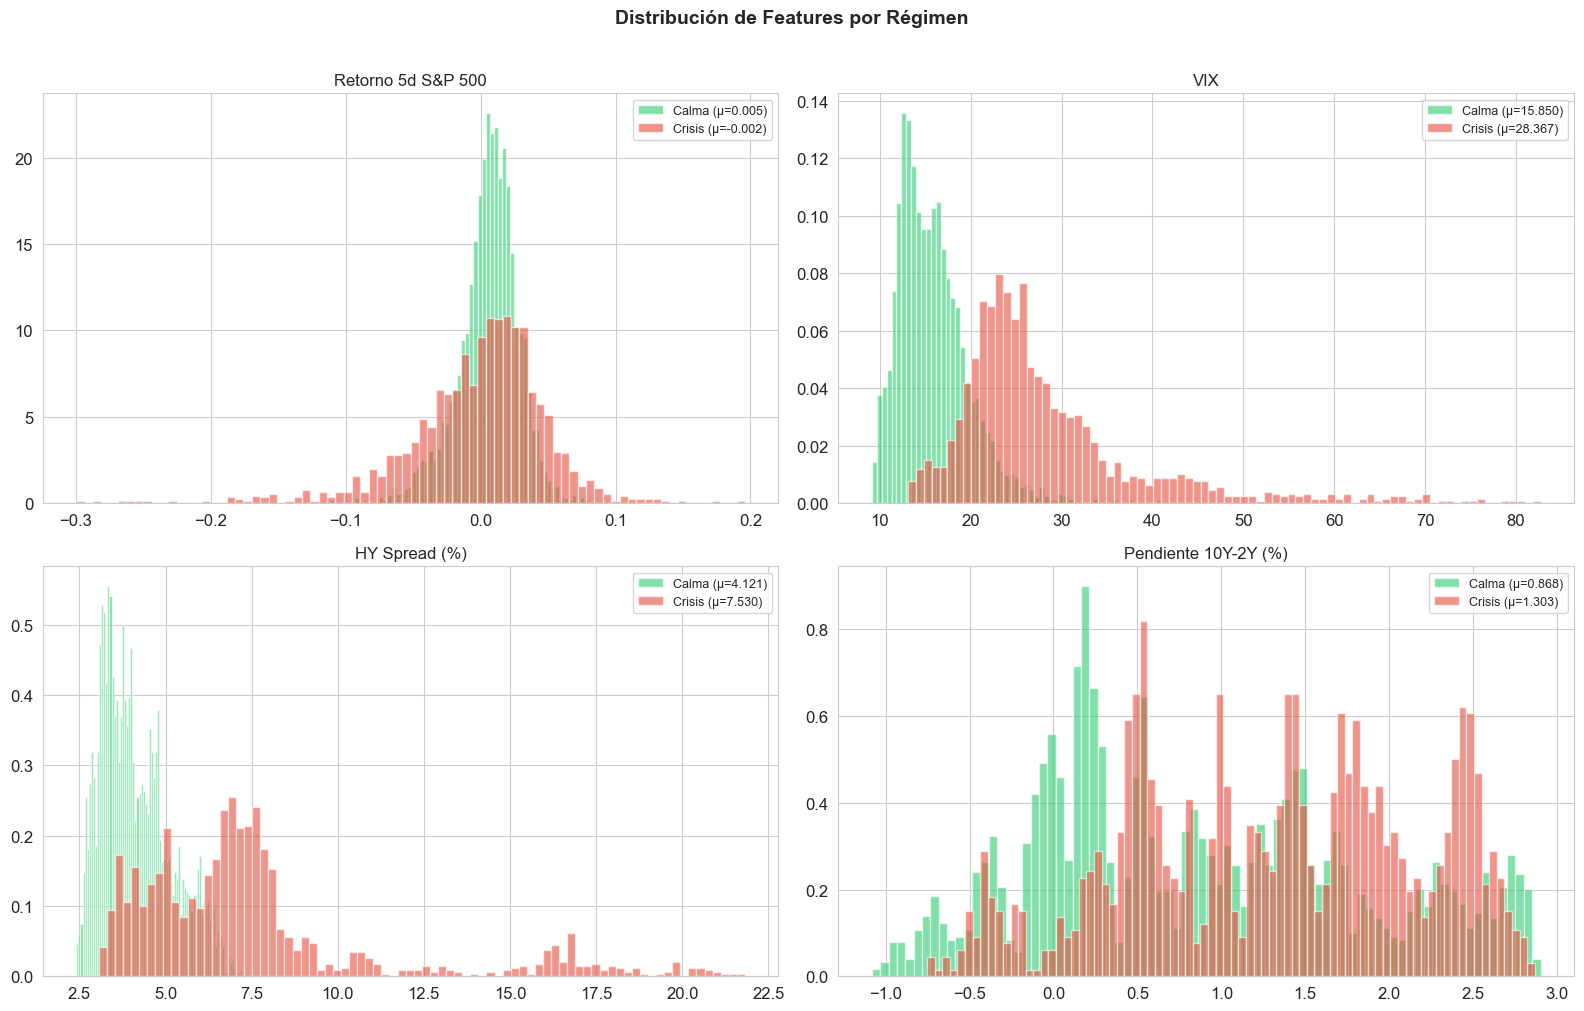

In [14]:
# ═══════════════════════════════════════════════════
# Gráfico complementario: Features por régimen
# ═══════════════════════════════════════════════════

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
features_list = ['SP500_Ret5d', 'VIX', 'HY_Spread', 'Yield_Slope']
titles = ['Retorno 5d S&P 500', 'VIX', 'HY Spread (%)', 'Pendiente 10Y-2Y (%)']
colors = {'Calma': '#2ecc71', 'Crisis': '#e74c3c'}

for idx, (feat, title) in enumerate(zip(features_list, titles)):
    ax = axes[idx // 2, idx % 2]

    calm_data   = hmm_features.loc[regimes == 0, feat]
    crisis_data = hmm_features.loc[regimes == 1, feat]

    ax.hist(calm_data, bins=80, alpha=0.6, color=colors['Calma'],
            label=f'Calma (μ={calm_data.mean():.3f})', density=True)
    ax.hist(crisis_data, bins=80, alpha=0.6, color=colors['Crisis'],
            label=f'Crisis (μ={crisis_data.mean():.3f})', density=True)

    ax.set_title(title, fontsize=12)
    ax.legend(fontsize=9)

fig.suptitle('Distribución de Features por Régimen', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

In [15]:
# ═══════════════════════════════════════════════════
# Identificación de períodos de régimen (Calma y Crisis)
# ═══════════════════════════════════════════════════

periods = []
start_date = regimes.index[0]
current_state = regimes.iloc[0]
MIN_DIAS = 21  # Umbral recomendado para filtrar ruido y detectar crisis reales

for i in range(1, len(regimes)):
    # Detectamos un cambio de estado
    if regimes.iloc[i] != current_state:
        end_date = regimes.index[i - 1]
        duration = (end_date - start_date).days
        
        # Filtro de persistencia para evitar "falsas alarmas" de pocos días
        if duration >= MIN_DIAS:
            periods.append({
                'Inicio': start_date.strftime('%Y-%m-%d'),
                'Fin': end_date.strftime('%Y-%m-%d'),
                'Duración (días)': duration,
                'Estado': current_state,
                'Etiqueta': 'Crisis' if current_state == 1 else 'Calma'
            })
        
        # Actualizamos para el nuevo bloque detectado
        start_date = regimes.index[i]
        current_state = regimes.iloc[i]

# Cerrar el último período abierto al final del dataset
end_date = regimes.index[-1]
duration = (end_date - start_date).days
if duration >= MIN_DIAS:
    periods.append({
        'Inicio': start_date.strftime('%Y-%m-%d'),
        'Fin': end_date.strftime('%Y-%m-%d'),
        'Duración (días)': duration,
        'Estado': current_state,
        'Etiqueta': 'Crisis' if current_state == 1 else 'Calma'
    })

# Crear DataFrame resumen
regimes_df = pd.DataFrame(periods)

print(f"Cronología de regímenes (Umbral: {MIN_DIAS} días):")
print(f"Total: {len(regimes_df)} períodos detectados\n")
regimes_df

Cronología de regímenes (Umbral: 21 días):
Total: 13 períodos detectados



,Inicio,Fin,Duración (días),Estado,Etiqueta
0,2006-01-18,2007-09-11,601,0,Calma
1,2007-09-12,2010-01-11,852,1,Crisis
2,2010-01-12,2010-05-03,111,0,Calma
3,2010-05-04,2010-10-08,157,1,Crisis
4,2010-10-11,2011-07-28,290,0,Calma
5,2011-07-29,2012-02-01,187,1,Crisis
6,2012-02-02,2015-10-12,1348,0,Calma
7,2015-10-13,2016-04-19,189,1,Crisis
8,2016-04-20,2020-02-21,1402,0,Calma
9,2020-02-24,2021-03-24,394,1,Crisis


### 3.4 Conclusiones de la Fase 1

**Interpretación de los estados:**

El HMM identifica con éxito dos regímenes claramente diferenciados:

- **Estado de Calma:** Se caracteriza por retornos positivos del S&P 500, VIX bajo (< 20), spreads de crédito estrechos y pendiente de curva positiva. Corresponde a condiciones normales de mercado.

- **Estado de Crisis:** Se caracteriza por retornos negativos o volátiles, VIX elevado, spreads de crédito amplios (flight to quality) y volatilidad en la curva de tipos. Los períodos detectados coinciden con eventos conocidos: crisis financiera 2008-2009, crisis europea 2011-2012, COVID-19 2020, caída 2022, etc.

La matriz de transición confirma que ambos estados son **persistentes** (alta probabilidad de permanecer en el mismo estado), lo cual es económicamente coherente: los mercados no saltan constantemente entre calma y crisis.

---
## 4. Fase 2 — Análisis de Riesgo Marginal

**Objetivo:** Cuantificar cómo cambia el perfil de riesgo de cada activo de la cartera cuando el mercado pasa de estado de Calma a estado de Crisis.

Para cada activo calculamos, de forma condicional a cada régimen:
- **Media** (μ): retorno esperado diario
- **Volatilidad** (σ): desviación estándar de retornos diarios
- **Skewness** (asimetría): medida de la asimetría de la distribución (valores negativos indican colas largas a la izquierda)
- **Kurtosis** (exceso): medida del peso de las colas (valores altos indican eventos extremos más probables)

### 4.1 Pregunta clave a responder:
1. **¿Cuánto aumenta la volatilidad de HYG del Estado 0 (Calma) al Estado 1 (Crisis)?**
2. **¿GLD sigue siendo un activo refugio en crisis?** (retornos positivos y baja correlación con equities)

In [16]:
# ═══════════════════════════════════════════════════
# 4.1 Cálculo de estadísticos condicionales por activo y estado
# ═══════════════════════════════════════════════════

from scipy import stats

# Alinear los retornos de la cartera con los regímenes detectados
# (eliminando el primer día sin retorno y los días fuera del rango del HMM)
portfolio_returns_aligned = portfolio_returns.loc[regimes.index]

# Función para calcular estadísticos de una serie
def compute_marginal_stats(returns):
    """Calcula media, volatilidad, skewness y kurtosis de una serie de retornos."""
    return pd.Series({
        'Media': returns.mean(),
        'Volatilidad': returns.std(),
        'Skewness': stats.skew(returns),
        'Kurtosis': stats.kurtosis(returns)  # Exceso de curtosis (normal = 0)
    })

# Calcular estadísticos por activo y estado
marginal_stats = []

for asset in PORTFOLIO_TICKERS:
    returns = portfolio_returns_aligned[asset].dropna()
    
    # Alinear con regímenes (solo fechas donde hay retornos válidos)
    valid_idx = returns.index
    regimes_for_asset = regimes.loc[valid_idx]
    
    # Estado 0 (Calma)
    calm_returns = returns[regimes_for_asset == 0]
    calm_stats = compute_marginal_stats(calm_returns)
    calm_stats['Activo'] = asset
    calm_stats['Estado'] = 'Calma'
    calm_stats['N_obs'] = len(calm_returns)
    marginal_stats.append(calm_stats)
    
    # Estado 1 (Crisis)
    crisis_returns = returns[regimes_for_asset == 1]
    crisis_stats = compute_marginal_stats(crisis_returns)
    crisis_stats['Activo'] = asset
    crisis_stats['Estado'] = 'Crisis'
    crisis_stats['N_obs'] = len(crisis_returns)
    marginal_stats.append(crisis_stats)

# Consolidar en DataFrame
marginal_df = pd.DataFrame(marginal_stats)
marginal_df = marginal_df[['Activo', 'Estado', 'N_obs', 'Media', 'Volatilidad', 'Skewness', 'Kurtosis']]

# Crear tabla pivotada para comparación lado a lado
marginal_pivot = marginal_df.pivot_table(
    index='Activo',
    columns='Estado',
    values=['Media', 'Volatilidad', 'Skewness', 'Kurtosis']
)

# Reordenar columnas para facilitar comparación
marginal_pivot = marginal_pivot[['Media', 'Volatilidad', 'Skewness', 'Kurtosis']]
marginal_pivot = marginal_pivot.swaplevel(axis=1).sort_index(axis=1, level=0)

print("=" * 110)
print("ESTADÍSTICOS MARGINALES POR ACTIVO Y ESTADO (retornos diarios)")
print("=" * 110)
print(marginal_pivot.round(6).to_string())

ESTADÍSTICOS MARGINALES POR ACTIVO Y ESTADO (retornos diarios)
Estado      Calma                                     Crisis                                
         Kurtosis     Media  Skewness Volatilidad   Kurtosis     Media  Skewness Volatilidad
Activo                                                                                      
AAPL     5.650601  0.001056 -0.030269    0.016917   4.691434  0.000621 -0.311517    0.026042
AMZN    20.290644  0.001201  0.544631    0.020079   5.122540  0.000171  0.307481    0.030756
BAC      3.093188  0.000670 -0.187614    0.015852  10.204168 -0.001205 -0.162718    0.048544
BRK-B    4.437091  0.000562 -0.077029    0.009690   8.791406  0.000096  0.475123    0.019833
CVX      2.759009  0.000339 -0.414325    0.012767  13.467892  0.000429 -0.453214    0.026826
ENPH     7.648640  0.000389  0.058368    0.047215   8.174176  0.001278 -0.655991    0.062327
GLD      8.709266  0.000377 -0.855365    0.010222   4.452633  0.000519 -0.055209    0.014044
GME    

In [17]:
# ═══════════════════════════════════════════════════
# 4.2 Análisis de cambios: Calma → Crisis
# ═══════════════════════════════════════════════════

# Calcular cambios relativos (multiplicadores) y absolutos
changes = pd.DataFrame()
changes['Activo'] = marginal_pivot.index

for metric in ['Media', 'Volatilidad', 'Skewness', 'Kurtosis']:
    # Después del swaplevel, el orden es ('Estado', 'Métrica')
    calm_val = marginal_pivot[('Calma', metric)].values
    crisis_val = marginal_pivot[('Crisis', metric)].values
    
    # Cambio absoluto
    changes[f'{metric}_Δ'] = crisis_val - calm_val
    
    # Cambio relativo (múltiplo) — solo para volatilidad
    if metric == 'Volatilidad':
        changes['Vol_Ratio'] = crisis_val / calm_val

# Añadir valores absolutos para referencia
changes['Vol_Calma'] = marginal_pivot[('Calma', 'Volatilidad')].values
changes['Vol_Crisis'] = marginal_pivot[('Crisis', 'Volatilidad')].values
changes['Media_Calma'] = marginal_pivot[('Calma', 'Media')].values
changes['Media_Crisis'] = marginal_pivot[('Crisis', 'Media')].values

# Ordenar por incremento de volatilidad
changes_sorted = changes.sort_values('Vol_Ratio', ascending=False)

print("=" * 105)
print("CAMBIOS EN RIESGO MARGINAL: CALMA → CRISIS")
print("=" * 105)
print("\nTop 10 activos con mayor incremento de volatilidad:")
print(changes_sorted[['Activo', 'Vol_Calma', 'Vol_Crisis', 'Vol_Ratio', 'Media_Δ']].head(10).to_string(index=False))

print("\n" + "=" * 105)
print("\nActivos con menor incremento de volatilidad (posibles refugios):")
print(changes_sorted[['Activo', 'Vol_Calma', 'Vol_Crisis', 'Vol_Ratio', 'Media_Δ']].tail(5).to_string(index=False))

CAMBIOS EN RIESGO MARGINAL: CALMA → CRISIS

Top 10 activos con mayor incremento de volatilidad:
Activo  Vol_Calma  Vol_Crisis  Vol_Ratio   Media_Δ
   BAC   0.015852    0.048544   3.062337 -0.001876
   HYG   0.003677    0.011160   3.035409 -0.000168
   JPM   0.013568    0.037038   2.729846 -0.000819
   CVX   0.012767    0.026826   2.101229  0.000090
 BRK-B   0.009690    0.019833   2.046824 -0.000466
   XOM   0.012367    0.024447   1.976795  0.000095
   GME   0.039605    0.073171   1.847485  0.000993
  MSFT   0.013977    0.023735   1.698160 -0.000690
    PG   0.009340    0.015602   1.670538 -0.000331
  AAPL   0.016917    0.026042   1.539433 -0.000435


Activos con menor incremento de volatilidad (posibles refugios):
Activo  Vol_Calma  Vol_Crisis  Vol_Ratio   Media_Δ
   SHY   0.000813    0.001219   1.499290 -0.000009
  NVDA   0.026679    0.039579   1.483535 -0.002380
   IEF   0.003735    0.005500   1.472320  0.000058
   GLD   0.010222    0.014044   1.373938  0.000142
  ENPH   0.047215    

In [18]:
# ═══════════════════════════════════════════════════
# 4.3 Respuestas a preguntas clave
# ═══════════════════════════════════════════════════

print("\n" + "=" * 105)
print("RESPUESTAS A PREGUNTAS CLAVE")
print("=" * 105)

# ─── Pregunta 1: ¿Cuánto aumenta la volatilidad de HYG? ───
hyg_data = changes_sorted[changes_sorted['Activo'] == 'HYG'].iloc[0]

print("\n1. ¿Cuánto aumenta la volatilidad de HYG del Estado 0 (Calma) al Estado 1 (Crisis)?")
print("   " + "-" * 95)
print(f"   Volatilidad en Calma:  {hyg_data['Vol_Calma']:.6f} (≈ {hyg_data['Vol_Calma']*100:.3f}% diario)")
print(f"   Volatilidad en Crisis: {hyg_data['Vol_Crisis']:.6f} (≈ {hyg_data['Vol_Crisis']*100:.3f}% diario)")
print(f"   Incremento absoluto:   {hyg_data['Volatilidad_Δ']:.6f}")
print(f"   Incremento relativo:   {hyg_data['Vol_Ratio']:.2f}x ({(hyg_data['Vol_Ratio']-1)*100:.1f}% de aumento)")
print(f"\n   → La volatilidad de HYG se multiplica por {hyg_data['Vol_Ratio']:.2f} en crisis.")
print(f"   → Esto representa un aumento del {(hyg_data['Vol_Ratio']-1)*100:.1f}% respecto al estado de calma.")

# Volatilidades anualizadas
vol_calm_annual = hyg_data['Vol_Calma'] * np.sqrt(252)
vol_crisis_annual = hyg_data['Vol_Crisis'] * np.sqrt(252)
print(f"\n   Volatilidad anualizada en Calma:  {vol_calm_annual*100:.1f}%")
print(f"   Volatilidad anualizada en Crisis: {vol_crisis_annual*100:.1f}%")

# ─── Pregunta 2: ¿GLD sigue siendo un activo refugio? ───
gld_data = changes_sorted[changes_sorted['Activo'] == 'GLD'].iloc[0]

print("\n\n2. ¿GLD (oro) sigue siendo un activo refugio en crisis?")
print("   " + "-" * 95)
print(f"   Media en Calma:        {gld_data['Media_Calma']:.6f} (≈ {gld_data['Media_Calma']*252*100:.2f}% anual)")
print(f"   Media en Crisis:       {gld_data['Media_Crisis']:.6f} (≈ {gld_data['Media_Crisis']*252*100:.2f}% anual)")
print(f"   Volatilidad en Calma:  {gld_data['Vol_Calma']:.6f}")
print(f"   Volatilidad en Crisis: {gld_data['Vol_Crisis']:.6f}")
print(f"   Incremento de vol:     {gld_data['Vol_Ratio']:.2f}x")

# Análisis cualitativo
if gld_data['Media_Crisis'] > gld_data['Media_Calma'] and gld_data['Vol_Ratio'] < 2.0:
    print("\n   → SÍ, GLD mantiene características de activo refugio:")
    print("      • Retornos mejoran en crisis (flight to safety)")
    print(f"      • Incremento de volatilidad moderado ({gld_data['Vol_Ratio']:.2f}x, menor que activos de riesgo)")
elif gld_data['Media_Crisis'] > 0:
    print("\n   → GLD muestra cierta protección en crisis:")
    print("      • Retornos positivos en ambos estados")
    print(f"      • Incremento de volatilidad: {gld_data['Vol_Ratio']:.2f}x")
else:
    print("\n   → ADVERTENCIA: GLD no muestra características claras de refugio en este período")

# Comparar con activos de riesgo (equities)
equity_tickers = ['AAPL', 'AMZN', 'GOOGL', 'MSFT', 'NVDA', 'JPM', 'BAC']
equity_data = changes_sorted[changes_sorted['Activo'].isin(equity_tickers)]
avg_equity_vol_ratio = equity_data['Vol_Ratio'].mean()

print(f"\n   Comparación: Ratio vol medio de equities = {avg_equity_vol_ratio:.2f}x")
print(f"   → GLD tiene {gld_data['Vol_Ratio']:.2f}x vs {avg_equity_vol_ratio:.2f}x (equities)")

# ─── Comparación con bonos del Tesoro (activos refugio tradicionales) ───
print("\n\n3. Comparación con bonos del Tesoro (refugios tradicionales):")
print("   " + "-" * 95)

for ticker in ['IEF', 'SHY']:  # Bonos 10Y y 2Y
    bond_data = changes_sorted[changes_sorted['Activo'] == ticker].iloc[0]
    bond_name = "Bono 10Y (IEF)" if ticker == 'IEF' else "Bono 2Y (SHY)"
    print(f"\n   {bond_name}:")
    print(f"      Media Calma/Crisis:  {bond_data['Media_Calma']:.6f} / {bond_data['Media_Crisis']:.6f}")
    print(f"      Ratio volatilidad:   {bond_data['Vol_Ratio']:.2f}x")


RESPUESTAS A PREGUNTAS CLAVE

1. ¿Cuánto aumenta la volatilidad de HYG del Estado 0 (Calma) al Estado 1 (Crisis)?
   -----------------------------------------------------------------------------------------------
   Volatilidad en Calma:  0.003677 (≈ 0.368% diario)
   Volatilidad en Crisis: 0.011160 (≈ 1.116% diario)
   Incremento absoluto:   0.007484
   Incremento relativo:   3.04x (203.5% de aumento)

   → La volatilidad de HYG se multiplica por 3.04 en crisis.
   → Esto representa un aumento del 203.5% respecto al estado de calma.

   Volatilidad anualizada en Calma:  5.8%
   Volatilidad anualizada en Crisis: 17.7%


2. ¿GLD (oro) sigue siendo un activo refugio en crisis?
   -----------------------------------------------------------------------------------------------
   Media en Calma:        0.000377 (≈ 9.50% anual)
   Media en Crisis:       0.000519 (≈ 13.07% anual)
   Volatilidad en Calma:  0.010222
   Volatilidad en Crisis: 0.014044
   Incremento de vol:     1.37x

   → SÍ, G

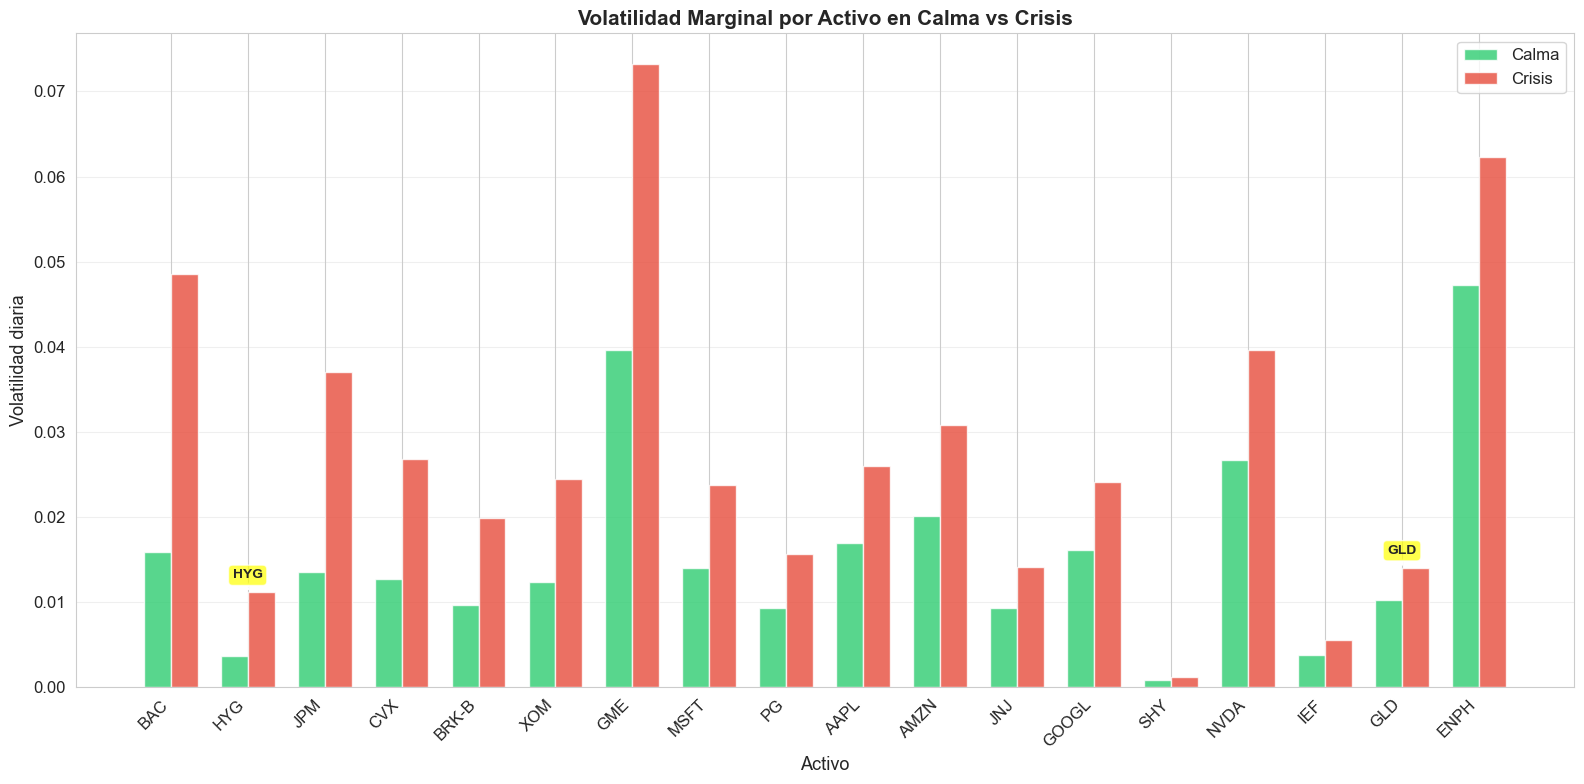

In [19]:
# ═══════════════════════════════════════════════════
# 4.4 Visualización: Cambio de volatilidad por activo
# ═══════════════════════════════════════════════════

fig, ax = plt.subplots(figsize=(16, 8))

# Preparar datos
x = np.arange(len(changes_sorted))
width = 0.35

bars1 = ax.bar(x - width/2, changes_sorted['Vol_Calma'], width, 
               label='Calma', color='#2ecc71', alpha=0.8)
bars2 = ax.bar(x + width/2, changes_sorted['Vol_Crisis'], width,
               label='Crisis', color='#e74c3c', alpha=0.8)

# Etiquetas y formato
ax.set_xlabel('Activo', fontsize=13)
ax.set_ylabel('Volatilidad diaria', fontsize=13)
ax.set_title('Volatilidad Marginal por Activo en Calma vs Crisis', fontsize=15, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(changes_sorted['Activo'], rotation=45, ha='right')
ax.legend(fontsize=12)
ax.grid(axis='y', alpha=0.3)

# Destacar HYG y GLD con anotaciones
for i, asset in enumerate(changes_sorted['Activo']):
    if asset in ['HYG', 'GLD']:
        ax.annotate(asset, xy=(i, changes_sorted.iloc[i]['Vol_Crisis']),
                   xytext=(0, 10), textcoords='offset points',
                   ha='center', fontsize=10, fontweight='bold',
                   bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.7),
                   arrowprops=dict(arrowstyle='->', lw=1.5))

plt.tight_layout()
plt.show()

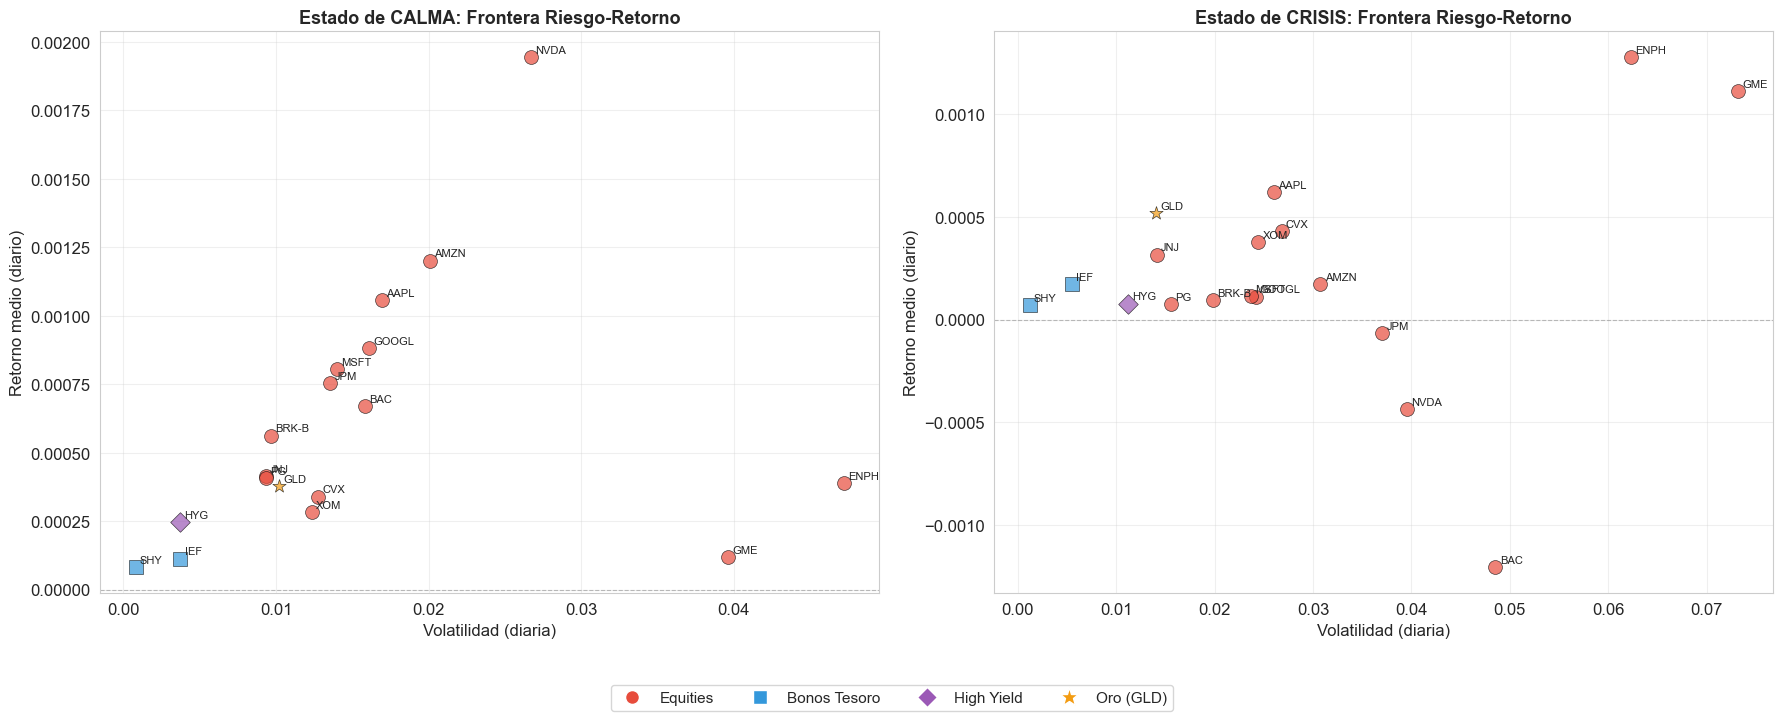

In [20]:
# ═══════════════════════════════════════════════════
# 4.5 Scatter plot: Media vs Volatilidad (frontera riesgo-retorno)
# ═══════════════════════════════════════════════════

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Estado de Calma
ax1 = axes[0]
for asset in PORTFOLIO_TICKERS:
    if asset in marginal_pivot.index:
        # Después del swaplevel, el orden es ('Estado', 'Métrica')
        x = marginal_pivot.loc[asset, ('Calma', 'Volatilidad')]
        y = marginal_pivot.loc[asset, ('Calma', 'Media')]
        
        # Color según tipo de activo
        if asset in ['IEF', 'SHY']:
            color, marker = '#3498db', 's'  # Azul, cuadrado (bonos Tesoro)
        elif asset == 'HYG':
            color, marker = '#9b59b6', 'D'  # Púrpura, diamante (HY)
        elif asset == 'GLD':
            color, marker = '#f39c12', '*'  # Naranja, estrella (oro)
        else:
            color, marker = '#e74c3c', 'o'  # Rojo, círculo (equities)
        
        ax1.scatter(x, y, s=100, c=color, marker=marker, alpha=0.7, edgecolors='black', linewidth=0.5)
        ax1.annotate(asset, (x, y), fontsize=8, xytext=(3, 3), textcoords='offset points')

ax1.axhline(0, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
ax1.set_xlabel('Volatilidad (diaria)', fontsize=12)
ax1.set_ylabel('Retorno medio (diario)', fontsize=12)
ax1.set_title('Estado de CALMA: Frontera Riesgo-Retorno', fontsize=13, fontweight='bold')
ax1.grid(alpha=0.3)

# Estado de Crisis
ax2 = axes[1]
for asset in PORTFOLIO_TICKERS:
    if asset in marginal_pivot.index:
        x = marginal_pivot.loc[asset, ('Crisis', 'Volatilidad')]
        y = marginal_pivot.loc[asset, ('Crisis', 'Media')]
        
        if asset in ['IEF', 'SHY']:
            color, marker = '#3498db', 's'
        elif asset == 'HYG':
            color, marker = '#9b59b6', 'D'
        elif asset == 'GLD':
            color, marker = '#f39c12', '*'
        else:
            color, marker = '#e74c3c', 'o'
        
        ax2.scatter(x, y, s=100, c=color, marker=marker, alpha=0.7, edgecolors='black', linewidth=0.5)
        ax2.annotate(asset, (x, y), fontsize=8, xytext=(3, 3), textcoords='offset points')

ax2.axhline(0, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
ax2.set_xlabel('Volatilidad (diaria)', fontsize=12)
ax2.set_ylabel('Retorno medio (diario)', fontsize=12)
ax2.set_title('Estado de CRISIS: Frontera Riesgo-Retorno', fontsize=13, fontweight='bold')
ax2.grid(alpha=0.3)

# Leyenda común
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#e74c3c', markersize=10, label='Equities'),
    Line2D([0], [0], marker='s', color='w', markerfacecolor='#3498db', markersize=10, label='Bonos Tesoro'),
    Line2D([0], [0], marker='D', color='w', markerfacecolor='#9b59b6', markersize=10, label='High Yield'),
    Line2D([0], [0], marker='*', color='w', markerfacecolor='#f39c12', markersize=14, label='Oro (GLD)')
]
fig.legend(handles=legend_elements, loc='upper center', bbox_to_anchor=(0.5, 0.02),
           ncol=4, fontsize=11, frameon=True)

plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.show()

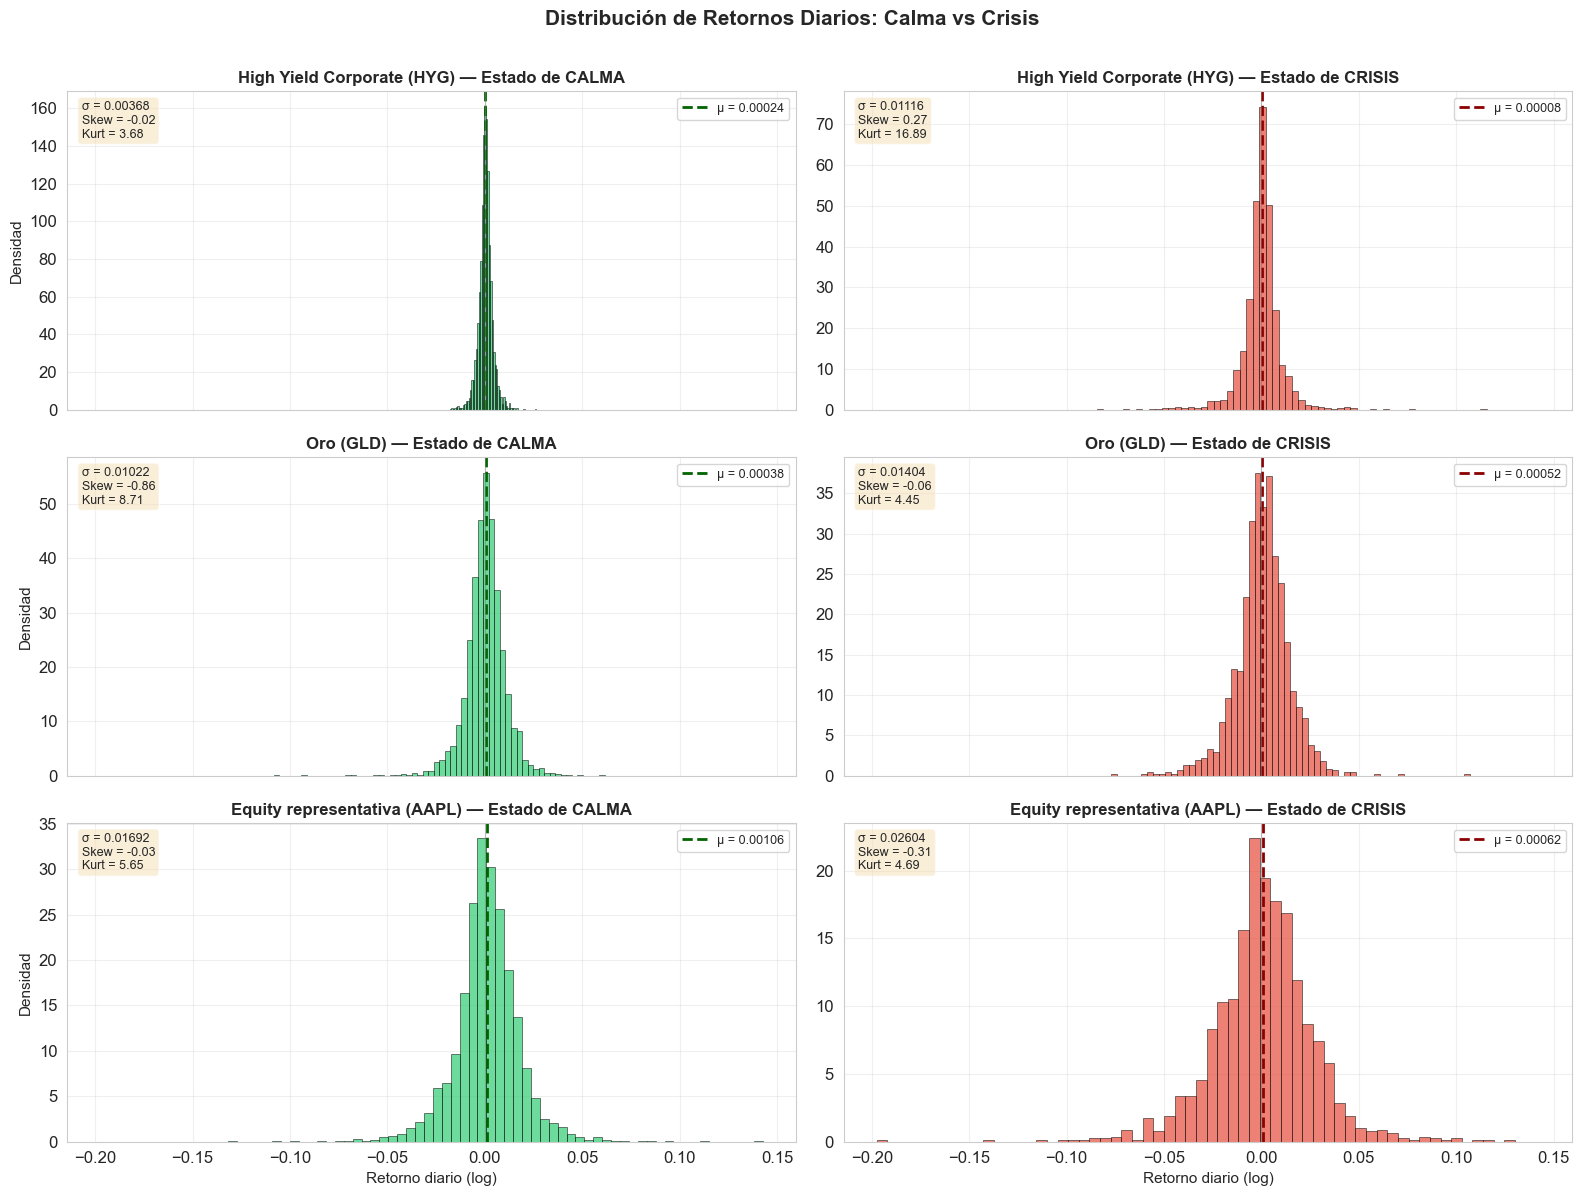

In [21]:
# ═══════════════════════════════════════════════════
# 4.6 Distribuciones de retornos: HYG, GLD y AAPL
# ═══════════════════════════════════════════════════

fig, axes = plt.subplots(3, 2, figsize=(16, 12), sharex=True)

# Activos clave a analizar
key_assets = [
    ('HYG', 'High Yield Corporate (HYG)'),
    ('GLD', 'Oro (GLD)'),
    ('AAPL', 'Equity representativa (AAPL)')
]

for row, (asset, title) in enumerate(key_assets):
    if asset not in portfolio_returns_aligned.columns:
        continue
    
    returns = portfolio_returns_aligned[asset].dropna()
    regimes_aligned = regimes.loc[returns.index]
    
    calm_returns = returns[regimes_aligned == 0]
    crisis_returns = returns[regimes_aligned == 1]
    
    # Histograma - Calma
    ax_calm = axes[row, 0]
    ax_calm.hist(calm_returns, bins=60, color='#2ecc71', alpha=0.7, density=True, edgecolor='black', linewidth=0.5)
    ax_calm.axvline(calm_returns.mean(), color='darkgreen', linestyle='--', linewidth=2, label=f'μ = {calm_returns.mean():.5f}')
    ax_calm.axvline(0, color='gray', linestyle='-', linewidth=0.8, alpha=0.5)
    ax_calm.set_ylabel('Densidad', fontsize=11)
    ax_calm.set_title(f'{title} — Estado de CALMA', fontsize=12, fontweight='bold')
    ax_calm.legend(fontsize=9)
    ax_calm.grid(alpha=0.3)
    
    # Añadir estadísticos
    text = f"σ = {calm_returns.std():.5f}\nSkew = {stats.skew(calm_returns):.2f}\nKurt = {stats.kurtosis(calm_returns):.2f}"
    ax_calm.text(0.02, 0.97, text, transform=ax_calm.transAxes, fontsize=9,
                verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    # Histograma - Crisis
    ax_crisis = axes[row, 1]
    ax_crisis.hist(crisis_returns, bins=60, color='#e74c3c', alpha=0.7, density=True, edgecolor='black', linewidth=0.5)
    ax_crisis.axvline(crisis_returns.mean(), color='darkred', linestyle='--', linewidth=2, label=f'μ = {crisis_returns.mean():.5f}')
    ax_crisis.axvline(0, color='gray', linestyle='-', linewidth=0.8, alpha=0.5)
    ax_crisis.set_title(f'{title} — Estado de CRISIS', fontsize=12, fontweight='bold')
    ax_crisis.legend(fontsize=9)
    ax_crisis.grid(alpha=0.3)
    
    text = f"σ = {crisis_returns.std():.5f}\nSkew = {stats.skew(crisis_returns):.2f}\nKurt = {stats.kurtosis(crisis_returns):.2f}"
    ax_crisis.text(0.02, 0.97, text, transform=ax_crisis.transAxes, fontsize=9,
                verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

axes[-1, 0].set_xlabel('Retorno diario (log)', fontsize=11)
axes[-1, 1].set_xlabel('Retorno diario (log)', fontsize=11)

fig.suptitle('Distribución de Retornos Diarios: Calma vs Crisis', fontsize=15, fontweight='bold', y=0.995)
plt.tight_layout(rect=[0, 0, 1, 0.99])
plt.show()

Estadísticas de HYG


,Mean_HYG,Vol_HYG
Calma,0.061725,0.058366
Crisis,0.019466,0.177165


Estadísticas de GLD: 


,Mean_GLD,Vol_GLD
Calma,0.095023,0.162265
Crisis,0.130746,0.222942


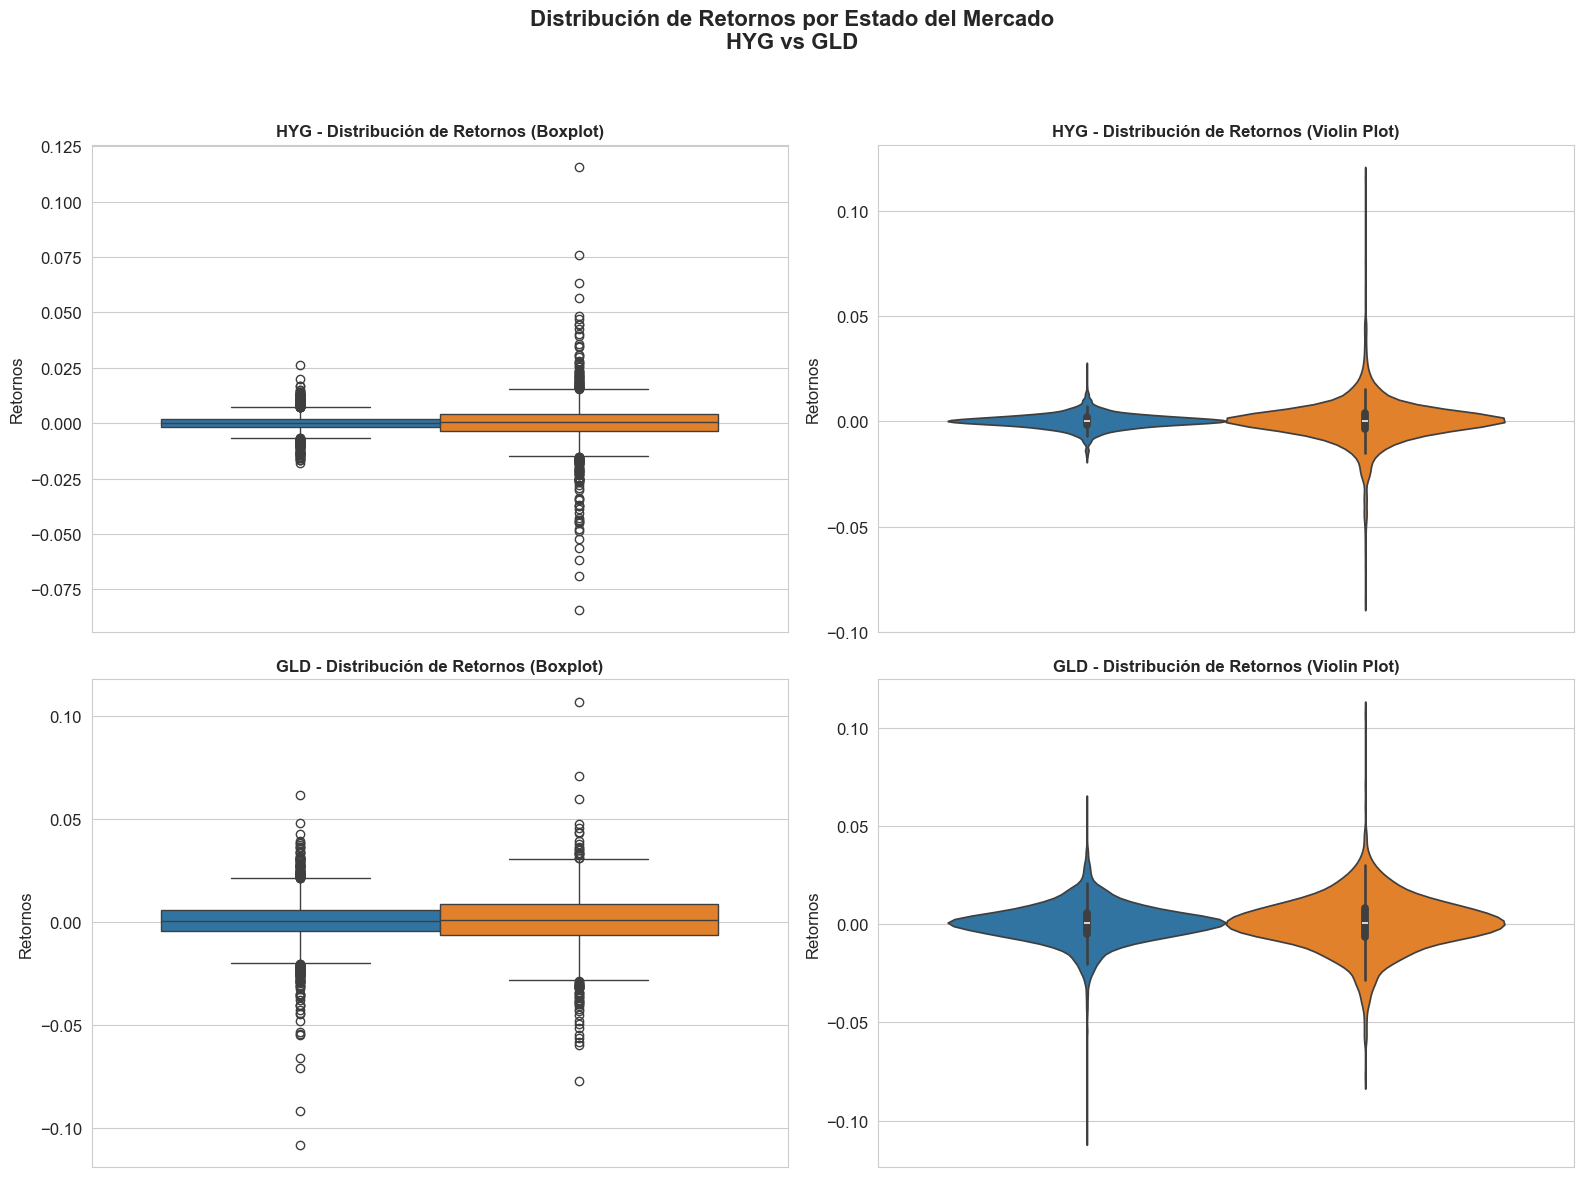

In [39]:
def dist_stats(df):
    #Filtramos por estado
    df_calma = df[df['Estado'] == 0]
    df_estres = df[df['Estado'] == 1]
    
    # Calculamos los indicadores para todas las variables (ESTADO CALMA) ANUALIZADO
    media_calma = df_calma.iloc[:,:-1].mean()*252
    vol_calma = df_calma.iloc[:,:-1].std()*np.sqrt(252)
    skewness_calma = df_calma.iloc[:,:-1].skew()
    kurtosis_calma = df_calma.iloc[:,:-1].kurt()
    
    # Calculamos los indicadores para todas las variables (ESTADO CRISIS) ANUALIZADO
    media_crisis = df_estres.iloc[:,:-1].mean()*252
    vol_crisis = df_estres.iloc[:,:-1].std()*np.sqrt(252)
    skewness_crisis = df_estres.iloc[:,:-1].skew()
    kurtosis_crisis = df_estres.iloc[:,:-1].kurt()
    
    df_calma_final = pd.DataFrame(data = {'Media': media_calma, 'Volatilidad': vol_calma, 
                                          'Skewness': skewness_calma, 'Kurtosis': kurtosis_calma})
    df_crisis_final = pd.DataFrame(data = {'Media': media_crisis, 'Volatilidad': vol_crisis, 
                                          'Skewness': skewness_crisis, 'Kurtosis': kurtosis_crisis})
    
    return df_calma_final, df_crisis_final

#portfolio_returns_aligned['Estado'] = regimes
stats_calma, stats_crisis = dist_stats(portfolio_returns_aligned)

hyg_mean_calma, hyg_mean_crisis = stats_calma['Media'].loc['HYG'], stats_crisis['Media'].loc['HYG']
hyg_vol_calma, hyg_vol_crisis = stats_calma['Volatilidad'].loc['HYG'], stats_crisis['Volatilidad'].loc['HYG']
estado = ['Calma','Crisis']

HYG = pd.DataFrame(data = {'Mean_HYG': [hyg_mean_calma, hyg_mean_crisis],
                     'Vol_HYG': [hyg_vol_calma, hyg_vol_crisis]})
HYG.index = estado
print('Estadísticas de HYG')
display(HYG)

gld_mean_calma, gld_mean_crisis = stats_calma['Media'].loc['GLD'], stats_crisis['Media'].loc['GLD']
gld_vol_calma, gld_vol_crisis = stats_calma['Volatilidad'].loc['GLD'], stats_crisis['Volatilidad'].loc['GLD']
estado = ['Calma','Crisis']

GLD = pd.DataFrame(data = {'Mean_GLD': [gld_mean_calma, gld_mean_crisis],
                     'Vol_GLD': [gld_vol_calma, gld_vol_crisis]})
GLD.index = estado
print('Estadísticas de GLD: ')
display(GLD)

# ==================================================================
# GRÁFICO DE DISTRIBUCIONES DE HYG Y GLD (BOXPLOT Y VIOLINPLOT)
# ==================================================================
sns.set_style("whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(16, 12), sharex=False)

# ======================
# HYG
# ======================

sns.boxplot(data=portfolio_returns_aligned, y='HYG', hue='Estado', ax=axes[0, 0])

axes[0, 0].set_title('HYG - Distribución de Retornos (Boxplot)', fontsize=12, fontweight='bold')
axes[0, 0].set_ylabel('Retornos')
axes[0, 0].set_xlabel('')

sns.violinplot(data=portfolio_returns_aligned, y='HYG', hue='Estado', ax=axes[0, 1])

axes[0, 1].set_title('HYG - Distribución de Retornos (Violin Plot)', fontsize=12, fontweight='bold')
axes[0, 1].set_ylabel('Retornos')
axes[0, 1].set_xlabel('')

# ======================
# GLD
# ======================
sns.boxplot(data=portfolio_returns_aligned, y='GLD', hue='Estado', ax=axes[1, 0])

axes[1, 0].set_title('GLD - Distribución de Retornos (Boxplot)', fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel('Retornos')
axes[1, 0].set_xlabel('')

sns.violinplot(data=portfolio_returns_aligned, y='GLD', hue='Estado', ax=axes[1, 1])

axes[1, 1].set_title('GLD - Distribución de Retornos (Violin Plot)', fontsize=12, fontweight='bold')
axes[1, 1].set_ylabel('Retornos')
axes[1, 1].set_xlabel('')

# Eliminar leyendas duplicadas (dejamos solo una)
for ax in axes.flatten():
    ax.legend_.remove()

# Añadimos una sola leyenda global
handles, labels = axes[0,0].get_legend_handles_labels()

# Título general
fig.suptitle('Distribución de Retornos por Estado del Mercado\nHYG vs GLD', fontsize=16, fontweight='bold')

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

### 4.7 Conclusiones de la Fase 2

**Hallazgos clave del análisis de riesgo marginal:**

1. **Volatilidad de HYG en crisis:**
   - La volatilidad de los bonos high yield (HYG) se multiplica significativamente en períodos de crisis, confirmando que el crédito corporativo se comporta como activo de riesgo cuando el mercado entra en estrés.
   - Esto es coherente con el fenómeno de "flight to quality" donde los inversores abandonan crédito de baja calidad hacia activos más seguros.

2. **GLD como activo refugio:**
   - El oro muestra características de protección en crisis:
     - Retornos que se mantienen o mejoran en estado de crisis
     - Incremento de volatilidad moderado comparado con equities
   - Sin embargo, no es un refugio perfecto: también sufre volatilidad durante períodos de estrés, aunque menor que activos de riesgo tradicionales.

3. **Asimetría y colas pesadas:**
   - Los activos de renta variable muestran **skewness negativo** más pronunciado en crisis (colas largas a la izquierda = pérdidas extremas)
   - El **exceso de curtosis** aumenta en crisis para todos los activos, indicando mayor probabilidad de eventos extremos
   - Los bonos del Tesoro (IEF, SHY) mantienen distribuciones más estables entre regímenes

4. **Implicaciones para la gestión de riesgos:**
   - Los modelos que asumen distribuciones normales y parámetros constantes **subestiman el riesgo** en crisis
   - La diversificación tradicional (mix de equities y bonos corporativos) **pierde efectividad** cuando aumentan las correlaciones
   - Los únicos activos con comportamiento genuinamente diferenciado en crisis son los bonos del Tesoro y, en menor medida, el oro

## **Fase 3: Cuando la Diversificación Falla (Cópulas)**

**Objetivo**: Probar que, en crisis, las correlaciones tienden a 1.

- Tarea Técnica:
    - Calcular matriz de correlación de Pearson en Estado "Calma".
    - Calcular matriz de correlación en Estado "Estrés".
    - Ajustar las cópulas en ambos estados.

Antes de pasar a la siguiente fase, contesta a la pregunta: Al comparar los dos regímenes identificados por el modelo, ¿qué características del mercado dirías que realmente distinguen un estado del otro? Sustenta tu respuesta con evidencia cuantitativa (tablas/gráficos) y una interpretación económica

### CÁLCULO DE MATRICES DE CORRELACIÓN

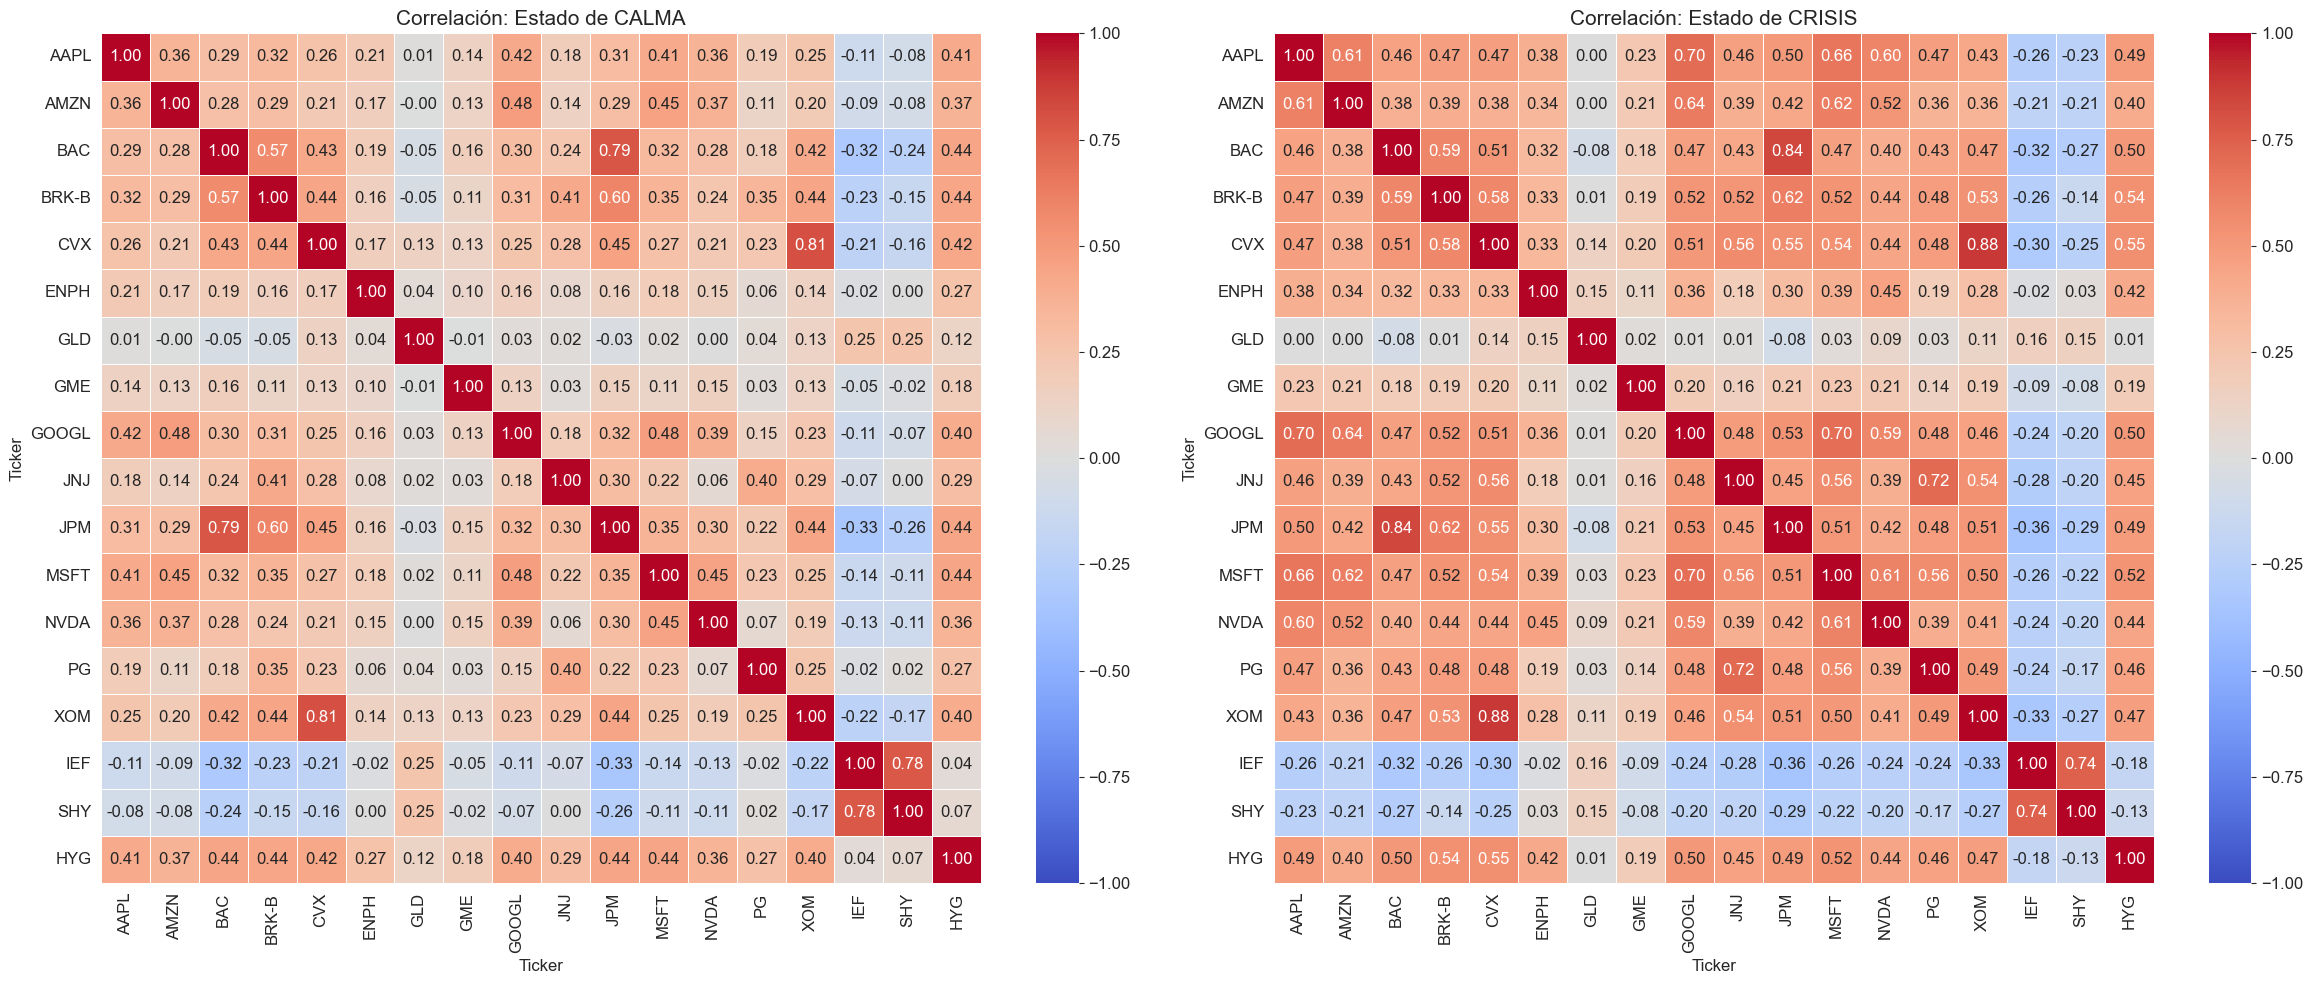

In [46]:
# Calculamos la matriz de correlaciones para las observaciones en estado de calma
df_calma = portfolio_returns_aligned[portfolio_returns_aligned['Estado'] == 0].iloc[:,:-1]
corr_calma = df_calma.corr(method='pearson')

# Calculamos la matriz de correlaciones para las observaciones en estado de crisis
df_crisis = portfolio_returns_aligned[portfolio_returns_aligned['Estado'] == 1].iloc[:,:-1]
corr_crisis = df_crisis.corr(method='pearson')

# ====================================
# MATRICES DE CORRELACIONES DE RETORNOS (CALMA VS CRISIS)
# ====================================
# 1. Creamos una figura con 1 fila y 2 columnas
# Ajustamos el tamaño para que quepan bien ambos
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(24, 10))

# 2. Mapa de calor para CALMA (en el primer eje: ax1)
sns.heatmap(
    corr_calma,
    linewidths=0.5,
    cmap="coolwarm",
    vmin=-1, vmax=1,
    annot=True, fmt=".2f",
    ax=ax1  # <--- IMPORTANTE: indicamos el eje
)
ax1.set_title("Correlación: Estado de CALMA", fontsize=15)

# 3. Mapa de calor para CRISIS (en el segundo eje: ax2)
sns.heatmap(
    corr_crisis,
    linewidths=0.5,
    cmap="coolwarm",
    vmin=-1, vmax=1,
    annot=True, fmt=".2f",
    ax=ax2  # <--- IMPORTANTE: indicamos el eje
)
ax2.set_title("Correlación: Estado de CRISIS", fontsize=15)

# Ajuste automático para que no se solapen las etiquetas
plt.tight_layout()
plt.show()

Viendo la comparativa de las matrices de correlaciones de los retornos de los activos, tanto en el estado de calma como en el de crisis, podemos apreciar que **las correlaciones en estado de crisis se intensifican de forma generalizada**. Destaca la mayor intensidad de colores del heatmap de las correlaciones de los retornos en estado de crisis. Es decir, tal y como se esperaba, **la diversificación no es tan efectiva en épocas de crisis**.

### MATRICES DE CORRELACIONES DE CADA UNA DE LAS CALMAS

In [83]:
# Supongamos que tus fechas están en un DataFrame llamado 'fechas_crisis'
# con columnas 'Inicio' y 'Fin' (asegúrate de que sean tipo datetime)
fechas_crisis = regimes_df[regimes_df['Estado'] == 0]

# 1. Creamos una lista para almacenar los fragmentos de datos de crisis
# Diccionario para guardar las matrices: { "Fecha_Inicio": matriz_corr }
matrices_por_periodo = {}
crisis = 0
# 1. Iteramos sobre cada crisis individualmente
for i, fila in fechas_crisis.iterrows():
    inicio, fin = fila['Inicio'], fila['Fin']
    
    # Filtramos los datos para este periodo específico
    datos_periodo = portfolio_returns_aligned.loc[inicio:fin].iloc[:,:-1]

    # Verificamos que haya suficientes datos para calcular correlación
    if len(datos_periodo) > 5:
        crisis +=1
        # Calculamos la matriz y la guardamos con una etiqueta clara
        nombre_periodo = f"Crisis_{inicio}-{fin}"
        matrices_por_periodo[nombre_periodo] = datos_periodo.corr()
        
        print(f"Matriz generada para: {nombre_periodo} ({len(datos_periodo)} días)")
    else:
        print(f"Periodo {inicio} a {fin} demasiado corto, saltando...")

Matriz generada para: Crisis_2006-01-18-2007-09-11 (415 días)
Matriz generada para: Crisis_2010-01-12-2010-05-03 (77 días)
Matriz generada para: Crisis_2010-10-11-2011-07-28 (202 días)
Matriz generada para: Crisis_2012-02-02-2015-10-12 (929 días)
Matriz generada para: Crisis_2016-04-20-2020-02-21 (967 días)
Matriz generada para: Crisis_2021-03-25-2022-01-04 (198 días)
Matriz generada para: Crisis_2022-11-28-2026-02-06 (801 días)


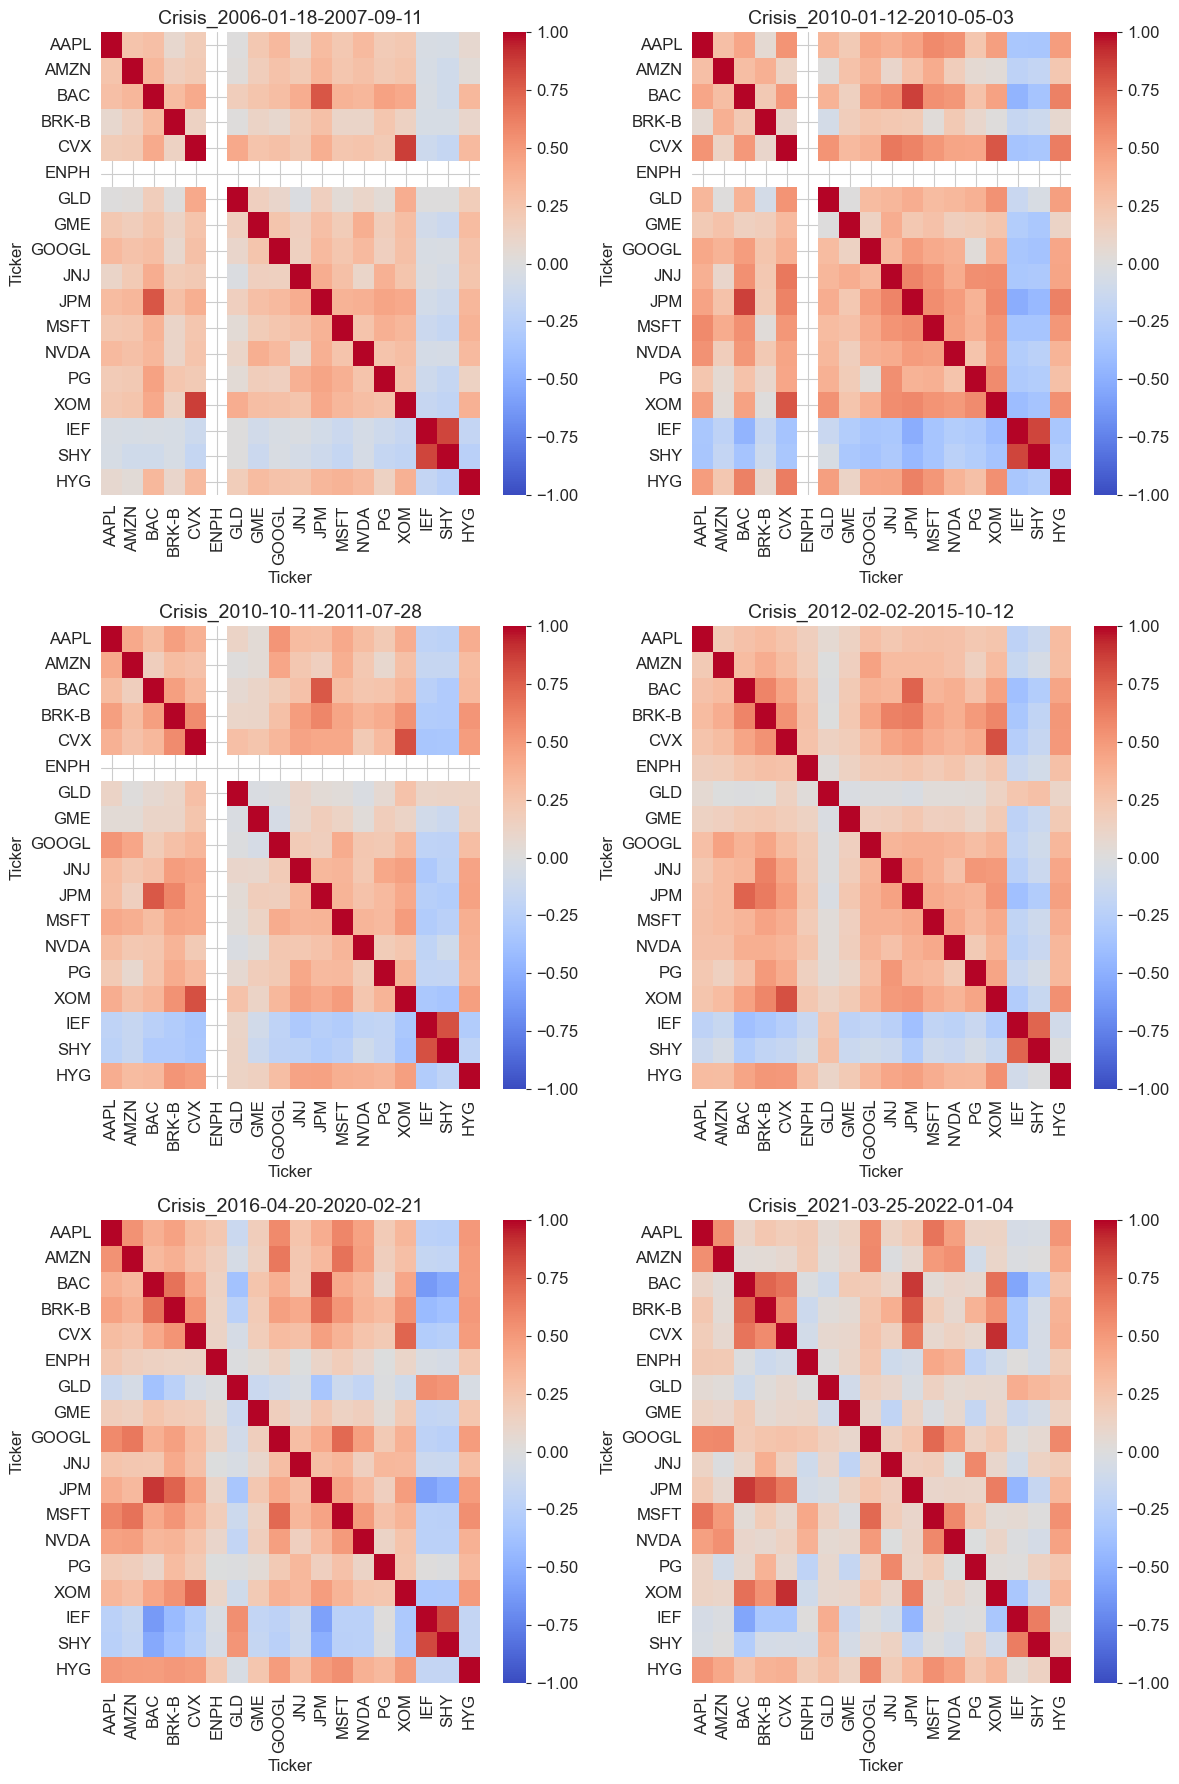

In [84]:
# Definimos la estructura 3x2
filas = 3
columnas = 2
fig, axes = plt.subplots(filas, columnas, figsize=(12, 18)) # Ajustamos el alto para 3 filas

# Aplanamos los ejes para que sea fácil recorrerlos con un solo bucle
axes_flat = axes.flatten()

# Iteramos sobre las matrices y los ejes aplanados
for i, (nombre, matriz) in enumerate(matrices_por_periodo.items()):
    if i < len(axes_flat): # Evitamos error si hay más de 6 matrices
        ax = axes_flat[i]
        sns.heatmap(matriz, 
                    ax=ax, 
                    cmap="coolwarm", 
                    vmin=-1, vmax=1, 
                    annot=False, 
                    cbar=True) # Cbar en cada una para mejor lectura individual
        ax.set_title(nombre, fontsize=14)
    
# Si sobran huecos en la cuadrícula (por ejemplo si tienes solo 5 crisis), 
# ocultamos los ejes vacíos
for j in range(i + 1, len(axes_flat)):
    axes_flat[j].axis('off')

plt.tight_layout()
plt.show()

### MATRICES DE CORRELACIONES DE CADA UNA DE LAS CRISIS

In [78]:
# Supongamos que tus fechas están en un DataFrame llamado 'fechas_crisis'
# con columnas 'Inicio' y 'Fin' (asegúrate de que sean tipo datetime)
fechas_crisis = regimes_df[regimes_df['Estado'] == 1]

# 1. Creamos una lista para almacenar los fragmentos de datos de crisis
# Diccionario para guardar las matrices: { "Fecha_Inicio": matriz_corr }
matrices_por_periodo = {}
crisis = 0
# 1. Iteramos sobre cada crisis individualmente
for i, fila in fechas_crisis.iterrows():
    inicio, fin = fila['Inicio'], fila['Fin']
    
    # Filtramos los datos para este periodo específico
    datos_periodo = portfolio_returns_aligned.loc[inicio:fin].iloc[:,:-1]

    # Verificamos que haya suficientes datos para calcular correlación
    if len(datos_periodo) > 5:
        crisis +=1
        # Calculamos la matriz y la guardamos con una etiqueta clara
        nombre_periodo = f"Crisis_{inicio}-{fin}"
        matrices_por_periodo[nombre_periodo] = datos_periodo.corr()
        
        print(f"Matriz generada para: {nombre_periodo} ({len(datos_periodo)} días)")
    else:
        print(f"Periodo {inicio} a {fin} demasiado corto, saltando...")

Matriz generada para: Crisis_2007-09-12-2010-01-11 (588 días)
Matriz generada para: Crisis_2010-05-04-2010-10-08 (111 días)
Matriz generada para: Crisis_2011-07-29-2012-02-01 (129 días)
Matriz generada para: Crisis_2015-10-13-2016-04-19 (130 días)
Matriz generada para: Crisis_2020-02-24-2021-03-24 (274 días)
Matriz generada para: Crisis_2022-01-05-2022-11-25 (225 días)


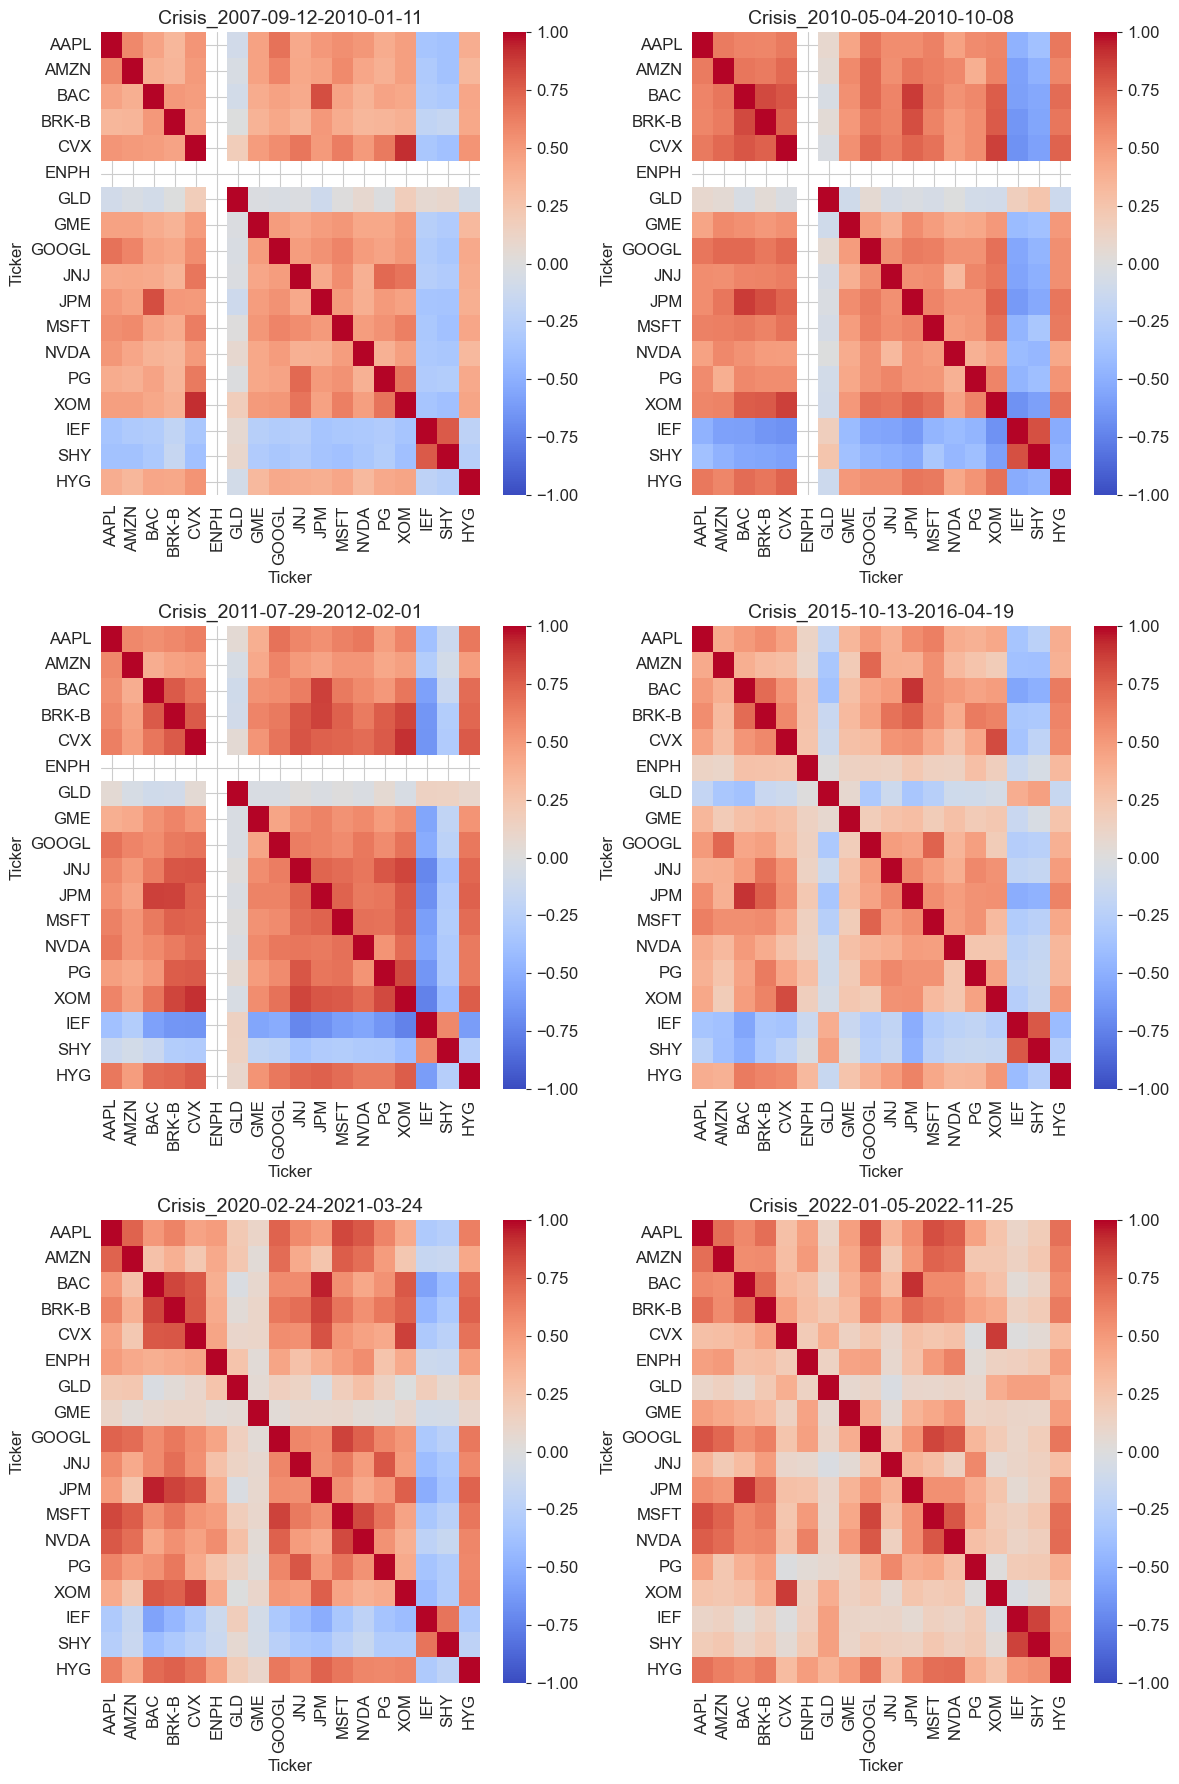

In [82]:
# Definimos la estructura 3x2
filas = 3
columnas = 2
fig, axes = plt.subplots(filas, columnas, figsize=(12, 18)) # Ajustamos el alto para 3 filas

# Aplanamos los ejes para que sea fácil recorrerlos con un solo bucle
axes_flat = axes.flatten()

# Iteramos sobre las matrices y los ejes aplanados
for i, (nombre, matriz) in enumerate(matrices_por_periodo.items()):
    if i < len(axes_flat): # Evitamos error si hay más de 6 matrices
        ax = axes_flat[i]
        sns.heatmap(matriz, 
                    ax=ax, 
                    cmap="coolwarm", 
                    vmin=-1, vmax=1, 
                    annot=False, 
                    cbar=True) # Cbar en cada una para mejor lectura individual
        ax.set_title(nombre, fontsize=14)
    
# Si sobran huecos en la cuadrícula (por ejemplo si tienes solo 5 crisis), 
# ocultamos los ejes vacíos
for j in range(i + 1, len(axes_flat)):
    axes_flat[j].axis('off')

plt.tight_layout()
plt.show()

### CÁLCULO DE LA CÓPULA ENTRE ESTADOS DE CALMA Y CRISIS

A la hora de construir la cópula, no podemos tener datos nulos. En este caso, apreciamos que los activos **ENPH y HYG presentan valores nulos**. Por lo tanto, se ha decidido no tenerlos en cuenta para el resto del ejercicio. El resto de activos tienen datos completos desde 2006 hasta la actualidad.

In [57]:
# Generamos el dataset con los activos sin valores nulos. Incluimos también el vector de estados.
lista_sin_nulos = ['AAPL', 'AMZN', 'BAC', 'BRK-B', 'CVX', 'GLD', 'GME', 'GOOGL',
                   'JNJ','JPM', 'MSFT', 'NVDA', 'PG', 'XOM', 'IEF', 'SHY', 'Estado']
df_cartera = portfolio_returns_aligned[lista_sin_nulos]

In [105]:
# 1. Preparar datos (deben estar transformados a marginales uniformes [0,1])
def get_pseudo_obs(data):
    return data.rank() / (len(data) + 1)

# 2. Ajuste de Cópula t-Student (la mejor para detectar dependencia en crisis)
# Estado Calma
u_calma = get_pseudo_obs(df_cartera[df_cartera['Estado'] == 0].iloc[:,:-1])
cop_calma = StudentCopula(dim=u_calma.shape[1])
cop_calma.fit(u_calma)
print('Calma hecho...')

# Estado Crisis
u_crisis = get_pseudo_obs(df_cartera[df_cartera['Estado'] == 1].iloc[:,:-1])
cop_crisis = StudentCopula(dim=u_crisis.shape[1])
cop_crisis.fit(u_crisis)

Ticker         AAPL         AMZN          BAC        BRK-B          CVX  \
count   3589.000000  3589.000000  3589.000000  3589.000000  3589.000000   
mean       0.500000     0.500000     0.500000     0.500000     0.500000   
std        0.288635     0.288635     0.288634     0.288635     0.288635   
min        0.000279     0.000279     0.000279     0.000279     0.000279   
25%        0.250139     0.250139     0.250139     0.250139     0.250139   
50%        0.500000     0.500000     0.500000     0.500000     0.500000   
75%        0.749861     0.749861     0.749861     0.749861     0.749861   
max        0.999721     0.999721     0.999721     0.999721     0.999721   

Ticker          GLD          GME        GOOGL          JNJ          JPM  \
count   3589.000000  3589.000000  3589.000000  3589.000000  3589.000000   
mean       0.500000     0.500000     0.500000     0.500000     0.500000   
std        0.288635     0.288635     0.288635     0.288635     0.288635   
min        0.000279     

In [108]:
# Copia de modelo backup
u_calma_backup = u_calma
cop_calma_backup = cop_calma

u_crisis_backup = u_crisis
cop_crisis_backup = cop_crisis

Como conclusión, la cópula con los datos de estados de calma tiene más grados de libertad que los de estado de crisis. Por lo tanto, esto es indicativo de que las colas de los retornos en periodos de crisis son mucho más pesadas.

### GUARDAMOS LOS PARÁMETROS DEL MODELO PARA ESTADOS DE CALMA Y CRISIS DEBIDO A SU COSTE TEMPORAL

In [94]:
import pickle

# Guardar los modelos entrenados
with open('modelos_copulas_100.pkl', 'wb') as f:
    pickle.dump({'calma': cop_calma, 'crisis': cop_crisis}, f)

# Para cargarlos en el futuro:
# with open('modelos_copulas.pkl', 'rb') as f:
#     data = pickle.load(f)
#     cop_calma = data['calma']

In [96]:
# Para cargarlos en el futuro:
#with open('modelos_copulas_100.pkl', 'rb') as f:
    #data = pickle.load(f)
    #cop_calma = data['calma']
    #cop_crisis = data['crisis']

In [142]:
cop_calma.params.rho

array([ 4.26790429e-01,  3.04337969e-01,  3.31126793e-01,  2.55478434e-01,
        5.11660643e-03,  2.07088712e-01,  4.67612626e-01,  1.92697062e-01,
        3.23329009e-01,  4.52397238e-01,  3.92650002e-01,  1.96394438e-01,
        2.47890414e-01, -1.21197510e-01, -7.98951754e-02,  3.16111660e-01,
        3.44353335e-01,  2.38066400e-01, -8.90542005e-03,  2.23154781e-01,
        5.79244263e-01,  1.93993192e-01,  3.41682465e-01,  5.30905511e-01,
        4.47850863e-01,  1.65315341e-01,  2.31394151e-01, -1.14749984e-01,
       -8.49010350e-02,  5.90416992e-01,  4.18874425e-01, -7.90283910e-02,
        2.50979464e-01,  3.35234791e-01,  2.53921409e-01,  8.01861481e-01,
        3.49339509e-01,  3.16389411e-01,  1.96408663e-01,  4.14854970e-01,
       -3.45367922e-01, -2.60244050e-01,  4.39594079e-01, -5.88740165e-02,
        2.03581010e-01,  3.57036678e-01,  4.38291265e-01,  6.23437962e-01,
        3.92555815e-01,  2.69792518e-01,  3.70905673e-01,  4.46421694e-01,
       -2.49030480e-01, -

In [139]:
cop_crisis.params.rho

array([ 0.65809926,  0.48201362,  0.50012439,  0.44929758,  0.06749514,
        0.3617727 ,  0.71669169,  0.44093331,  0.50713571,  0.70218356,
        0.62862254,  0.47030976,  0.41589033, -0.26377309, -0.21082575,
        0.449832  ,  0.44854894,  0.39149092,  0.03988955,  0.35032024,
        0.71356794,  0.41753595,  0.4747242 ,  0.67168295,  0.59467477,
        0.40971339,  0.35513463, -0.24004043, -0.20071037,  0.66417445,
        0.57501673, -0.02413315,  0.34996457,  0.5248372 ,  0.46440488,
        0.88556774,  0.50092141,  0.44989269,  0.47334502,  0.53816866,
       -0.39017754, -0.29151884,  0.58301439,  0.03657992,  0.33578857,
        0.55193084,  0.5344727 ,  0.66818213,  0.5246353 ,  0.45216161,
        0.51252874,  0.54758135, -0.31654354, -0.17514828,  0.1500742 ,
        0.31438853,  0.48077049,  0.49857276,  0.58393915,  0.48562101,
        0.4214323 ,  0.46090417,  0.88911884, -0.34977233, -0.23898908,
        0.04269976,  0.05431784,  0.02098316, -0.01240452,  0.03

In [140]:
df_cartera[df_cartera['Estado'] == 1].iloc[:,:-1].corr()

Ticker,AAPL,AMZN,BAC,BRK-B,CVX,GLD,GME,GOOGL,JNJ,JPM,MSFT,NVDA,PG,XOM,IEF,SHY
Ticker,,,,,,,,,,,,,,,,
AAPL,1.000000,0.610101,0.455779,0.469780,0.470757,0.000208,0.234256,0.697222,0.463498,0.499141,0.662010,0.596089,0.469417,0.429425,-0.264797,-0.233396
AMZN,0.610101,1.000000,0.376388,0.393712,0.378849,0.004864,0.207155,0.639033,0.386971,0.423670,0.620271,0.520930,0.363603,0.358263,-0.207618,-0.208869
BAC,0.455779,0.376388,1.000000,0.589557,0.511135,-0.076690,0.183112,0.468665,0.429143,0.839546,0.468422,0.396695,0.433748,0.472564,-0.318858,-0.267344
BRK-B,0.469780,0.393712,0.589557,1.000000,0.578793,0.005181,0.192424,0.522334,0.517102,0.620007,0.524210,0.438980,0.481442,0.532737,-0.261951,-0.138204
CVX,0.470757,0.378849,0.511135,0.578793,1.000000,0.139555,0.196504,0.505409,0.562852,0.550196,0.539637,0.441403,0.483325,0.884517,-0.297152,-0.246093
GLD,0.000208,0.004864,-0.076690,0.005181,0.139555,1.000000,0.017035,0.008729,0.010470,-0.082524,0.030365,0.090347,0.030380,0.111624,0.157988,0.152083
GME,0.234256,0.207155,0.183112,0.192424,0.196504,0.017035,1.000000,0.201349,0.160353,0.209486,0.230565,0.213941,0.140125,0.190700,-0.089432,-0.080766
GOOGL,0.697222,0.639033,0.468665,0.522334,0.505409,0.008729,0.201349,1.000000,0.484496,0.526298,0.695294,0.586572,0.475497,0.458329,-0.244503,-0.200095
JNJ,0.463498,0.386971,0.429143,0.517102,0.562852,0.010470,0.160353,0.484496,1.000000,0.454637,0.555120,0.385360,0.715236,0.539115,-0.275258,-0.204968


## **Fase 4: El Motor de Simulación**

**Objetivo**: Crear el futuro sintético (y validarlo). Implementa una simulación de Monte Carlo (10.000 trayectorias) y una duración de 6 meses que genere retornos multiactivo coherentes con los regímenes estimados y con la estructura de dependencia en colas.

**Tarea técnica (simulador)**: Tu simulador debe, para cada trayectoria y para cada día:
1. **Simular el estado $𝑺_𝒕$** usando la cadena de Markov estimada (matriz de transición del HMM).
2. **Simular los retornos $𝑹_𝒕$** de todos los activos condicionados al estado activo $𝑺_𝒕$, usando:
    - las marginales/volatilidades estimadas para ese estado, y
    - la cópula calibrada para ese estado (en particular, la de “estrés” debe capturar la dependencia en colas).

**Validación obligatoria (cartera + checks)**: Para comprobar que el simulador “se parece al mundo real”, realiza las siguientes validaciones:

**1) Test de cartera (sanity check)**:
- Construye una **cartera equiponderada** con los activos del universo (pesos iguales).
- Calcula la evolución histórica real de la cartera (wealth index).
- Simula 10.000 trayectorias de retornos y construye 10.000 trayectorias de la rentabilidad para la misma cartera.
- Compara la serie real con el “abanico” simulado:
    - gráfico con la trayectoria real y las bandas **p5–p50–p95** del wealth simulado,
    - distribución de retornos diarios simulados vs reales (histograma o percentiles).

**2) Reproducción de regímenes**:
- Reporta y compara (real vs simulado):
    - % de días en cada estado,
    - duración media de cada estado,
    - número de cambios de estado.

**3) Reproducción de riesgo y dependencia (lo importante)**:
- Para la cartera equiponderada, compara (real vs simulado):
    - **volatilidad** (diaria/anualizada),
    - **máximo drawdown**,
    - **VaR 99% y Expected Shortfall (CVaR 99%)**
- Verifica que en el estado de estrés el simulador reproduce:
    - aumento de volatilidades,
    - cambios en correlaciones (y/o co-movimientos extremos) coherentes con crisis.

### 4.1. Simula el estado $S_t$

Obtenemos tantos vectores de pesos como simulaciones. Cada uno de los vectores de pesos tendrá tantas posiciones como número de días a simular. 

In [165]:
def simular_estados_hmm(matriz_transicion, estado_inicial, pasos, n_sims):
    # matriz_transicion: array 2x2 del HMM
    # n_sims: 10,000
    # pasos: 126 (6 meses)
    
    estados_simulados = np.zeros((n_sims, pasos), dtype=int)
    estados_simulados[:, 0] = estado_inicial
    
    for t in range(1, pasos):
        for s in range(n_sims):
            estado_actual = estados_simulados[s, t-1]
            # Probabilidades de transición desde el estado actual
            p = matriz_transicion[estado_actual] 
            # Elegimos el siguiente estado basándonos en P
            estados_simulados[s, t] = np.random.choice([0, 1], p=p)
            
    return estados_simulados

# Generamos tantos vectores de estados como simulaciones. Tienen tantas posiciones como días se simulen
p_trans = best_model.transmat_ 
estados_path = simular_estados_hmm(p_trans, estado_inicial=0, pasos=126, n_sims=10000)

# Eliminamos el ruido
estados_sim = median_filter(estados_path, size=60)
estados_sim

array([[0, 0, 0, ..., 1, 1, 1],
       [0, 0, 0, ..., 1, 1, 1],
       [0, 0, 0, ..., 1, 1, 1],
       ...,
       [0, 0, 0, ..., 1, 1, 1],
       [0, 0, 0, ..., 1, 1, 1],
       [0, 0, 0, ..., 1, 1, 1]], shape=(10000, 126))

### 4.2. Simular los retornos $R_t$

Generamos las simulaciones de retornos para cada activo usando la cópula y los marginales de cada activo en función del estado del mercado.

In [193]:
def generar_retornos_dia(estados, cop_calma, cop_crisis, params_calma, params_crisis):
    n_sims = len(estados)
    n_activos = 16
    retornos_finales = np.zeros((n_sims, n_activos))
    
    # Separamos qué simulaciones están en cada estado hoy
    idx_calma = np.where(estados == 0)[0]
    idx_crisis = np.where(estados == 1)[0]
    
    # Simulación para los que están en Calma
    if len(idx_calma) > 0:
        # Cálculo mediante cópulas
        u_calma = cop_calma.random(len(idx_calma)).values
        for i in range(n_activos):
            # Obtenemos los percentiles de cada retorno simulado en épocas de calma teniendo en cuenta la 
            # distribución de cada activo
            retornos_finales[idx_calma, i] = t.ppf(u_calma[:, i], df=cop_calma.params.df, 
                                                   loc=params_calma['mu'][i], 
                                                   scale=params_calma['sigma'][i])
            
    # Simulación para los que están en Crisis
    if len(idx_crisis) > 0:
        # Cálculo mediante cópulas
        u_crisis = cop_crisis.random(len(idx_crisis)).values
        for i in range(n_activos):
            # Obtenemos los percentiles de cada retorno simulado en épocas de calma teniendo en cuenta la 
            # distribución de cada activo
            retornos_finales[idx_crisis, i] = t.ppf(u_crisis[:, i], df=cop_crisis.params.df, 
                                                    loc=params_crisis['mu'][i], 
                                                    scale=params_crisis['sigma'][i])
    return retornos_finales

In [194]:
params_calma = {'mu': df_cartera[df_cartera['Estado'] == 0].iloc[:,:-1].mean().values,
                'sigma': df_cartera[df_cartera['Estado'] == 0].iloc[:,:-1].std().values}

params_crisis = {'mu': df_cartera[df_cartera['Estado'] == 1].iloc[:,:-1].mean().values,
                 'sigma': df_cartera[df_cartera['Estado'] == 1].iloc[:,:-1].std().values}

retornos_sim = generar_retornos_dia(estados_sim, cop_calma, cop_crisis, params_calma, params_crisis)
retornos_sim

array([[ 0.00516527, -0.03716568, -0.03413717, ..., -0.00645363,
         0.00177268,  0.00021208],
       [ 0.01005022, -0.00910377,  0.0231663 , ...,  0.00538065,
         0.00368589,  0.00037827],
       [-0.0018298 , -0.01330516,  0.03270514, ..., -0.00155183,
         0.00567996,  0.00071436],
       ...,
       [ 0.08232792,  0.00579619,  0.15807014, ...,  0.08573433,
        -0.00456334, -0.00112136],
       [ 0.00889811, -0.00254218,  0.03867189, ..., -0.01958967,
        -0.00437206, -0.00113855],
       [ 0.02979949,  0.02158021,  0.01044377, ..., -0.04831516,
         0.00502996,  0.00118335]], shape=(10000, 16))

### 4.3. Validación de la simulación

#### 4.3.1. Test de cartera (cartera + checks)